<a href="https://colab.research.google.com/github/jeancguzman2050/OKR-Data-Driven/blob/main/Hoteles_AQ_Inn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [160]:
# this will help in making the Python code more structured automatically (good coding practice)

#%load_ext nb_black

# Libraries to help with reading and manipulating data

import numpy as np

import pandas as pd

# Libraries to help with data visualization

import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# **Introducción: Optimización de la Gestión de Reservas en AQ Inn Hotels Group**

En la industria hotelera contemporánea, la gestión eficiente de las reservas y la previsibilidad de los ingresos son pilares fundamentales para la sostenibilidad del negocio. Uno de los mayores desafíos que enfrentan los hoteles es la **tasa de cancelación**, un fenómeno que no solo genera incertidumbre operativa, sino que también impacta directamente en la rentabilidad neta y en la planificación de recursos.

Este proyecto presenta un análisis exhaustivo del conjunto de datos de **AQ Inn Hotels Group**, con el objetivo de:

1.  **Comprender el Comportamiento del Cliente:** Identificar patrones demográficos, preferencias de servicios (comidas, tipos de habitación) y canales de reserva predominantes.
2.  **Analizar Factores de Riesgo:** Determinar qué variables, como el tiempo de antelación (*lead time*) o las solicitudes especiales, influyen decisivamente en la probabilidad de que una reserva sea cancelada.
3.  **Desarrollar Inteligencia Predictiva:** Implementar modelos de Machine Learning (Random Forest) capaces de anticipar cancelaciones con un alto grado de precisión.
4.  **Acción Estratégica:** Traducir los hallazgos estadísticos en una hoja de ruta operativa y en objetivos de negocio (OKRs) orientados a resultados (*outcomes*).

A través de este enfoque integral, AQ Inn Hotels Group busca transitar de una gestión reactiva a una **estrategia proactiva basada en datos**, asegurando una ventaja competitiva en el mercado actual.

In [161]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
# read the dataset

df = pd.read_csv('/content/drive/MyDrive/OKRs_Data_Driven_Hotel_Booking/AQINNHotelsGroup.csv')

In [163]:
# Asignar Estadisticos
def getEstatisticalValues(column):
  minimo=column.min()
  maximo = column.max()
  mediana = column.median()
  media = column.mean()
  desviacion_estandar=column.std()
  varianza = desviacion_estandar **2
  cuartiles = column.quantile([0.25,0.5,0.75])
  asimetria = column.sesgo()
  curtosis=column.kustosis()
  print ("minimo:", minimo)
  print ("maximo:", maximo)
  print ("mediana:", mediana)
  print ("media:", media)
  print("Desv Std: ", desviacion_estandar)
  print("Cuartiles: \n", cuartiles)
  print("Asimetria: ", asimetria)
  print("Curtosis: ", curtosis)


In [164]:

df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [166]:
df.isna().sum()


,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [167]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [169]:
# Creando copia del dataframe

dfVirtual = df.copy()

En primer lugar, se intento comprender el significado de todas las columnas del marco de datos. Para ello, veremos los valores únicos obtenidos por cada columna cuyo significado no logramos comprender.

In [170]:
dfVirtual['Booking_ID'].unique()

array(['INN00001', 'INN00002', 'INN00003', ..., 'INN36273', 'INN36274',
       'INN36275'], dtype=object)

In [171]:
dfVirtual['booking_status'].unique()

array(['Not_Canceled', 'Canceled'], dtype=object)

In [172]:
dfVirtual['arrival_year'].unique()

array([2017, 2018])

In [173]:
dfVirtual['type_of_meal_plan'].unique()

array(['Meal Plan 1', 'Not Selected', 'Meal Plan 2', 'Meal Plan 3'],
      dtype=object)

In [174]:
dfVirtual['market_segment_type'].unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

In [175]:
dfVirtual['no_of_children'].unique()

array([ 0,  2,  1,  3, 10,  9])

**LIMPIEZA DE LOS DATOS**

Limpiar los datos es un paso crucial antes de la EDA, ya que eliminará los datos ambiguos que pueden afectar el resultado de la EDA.

Durante la limpieza de datos, realizaremos los siguientes pasos: Eliminar filas duplicadas, Gestionar valores faltantes, Convertir columnas a tipos de datos adecuados y Añadir columnas importantes

**1. Eliminar filas duplicadas si las hay**

In [61]:
dfVirtual[dfVirtual.duplicated()].shape   # Mostrar el número de filas de filas duplicadas filas duplicadas

(0, 19)

In [176]:
dfVirtual.drop_duplicates(inplace = True) # Eliminación de valores duplicados

In [177]:
dfVirtual.shape

(36275, 19)

**2. Manejo de valores faltantes.**

In [178]:
dfVirtual.isnull().sum().sort_values(ascending = False)[:6]

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0


No se encotraron valores faltantes

In [179]:
dfVirtual['no_of_children'].unique()

array([ 0,  2,  1,  3, 10,  9])

La columna "no-of-children" tiene el valor 0, lo que significa que no hay hijos en el grupo de clientes que realizó esa transacción.

In [180]:
dfVirtual.isnull().sum().sort_values(ascending = False)[:6] # Comprobación de si se han eliminado todos los valores nulos

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0


**No se encontraron valores nulos**

Hay algunas filas con un total de cero de adultos o niños. Por lo tanto, fueron eliminadas.

In [184]:
dfVirtual[dfVirtual['no_of_adults']+dfVirtual['no_of_children'] == 0].shape

(0, 19)

In [69]:
dfVirtual.drop(dfVirtual[dfVirtual['no_of_adults']+dfVirtual['no_of_children'] == 0].index, inplace = True)

**3. Conversión de columnas a tipos de datos apropiados.**

In [185]:
# Eliminamos los valores del Precio Promedio por Habitación > 1000
dfVirtual.drop(dfVirtual[dfVirtual['avg_price_per_room'] > 500].index, inplace = True)

**4. Agregar columnas importantes.**

In [186]:
# Agregar el número total de personas como columna, es decir, el número total de personas = número de adultos + niños
dfVirtual['total_people'] = dfVirtual['no_of_adults'] + dfVirtual['no_of_children']

In [187]:
# Agregar la columna Fecha a partir de las columnas individuales de año, mes y día (Esta Columna es de Tipo Strim)
dfVirtual['arrival_date_str'] = dfVirtual['arrival_year'].astype(str) + '-' + dfVirtual['arrival_month'].astype(str) + '-' + dfVirtual['arrival_date'].astype(str)

# Ahora, se usa pd.to_datetime en la columna combinada de tipo string (Esta Columna es de Tipo datatime)
dfVirtual['arrival_dateTime'] = pd.to_datetime(dfVirtual['arrival_date_str'], errors='coerce')

# Eliminamos, la columna intermediaria de tipo string
dfVirtual.drop('arrival_date_str', axis=1, inplace=True)


In [188]:
# Agregar la columna Duración de la Estancia a partir de las columnas individuales "no_of_weekend_nights" y  , mes y día (Esta Columna es de Tipo Strim)
dfVirtual['total_stay_length'] = dfVirtual['no_of_weekend_nights'] + dfVirtual['no_of_week_nights']

In [189]:
dfVirtual

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_people,arrival_dateTime,total_stay_length
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,Offline,0,0,0,65.00,0,Not_Canceled,2,2017-10-02,3
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,Online,0,0,0,106.68,1,Not_Canceled,2,2018-11-06,5
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,Online,0,0,0,60.00,0,Canceled,1,2018-02-28,3
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,Online,0,0,0,100.00,0,Canceled,2,2018-05-20,2
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,Online,0,0,0,94.50,0,Canceled,2,2018-04-11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,...,Online,0,0,0,167.80,1,Not_Canceled,3,2018-08-03,8
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,...,Online,0,0,0,90.95,2,Canceled,2,2018-10-17,4
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,...,Online,0,0,0,98.39,2,Not_Canceled,2,2018-07-01,8
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,...,Online,0,0,0,94.50,0,Canceled,2,2018-04-21,3


**ANALISIS EXPLORATORIO DE DATOS O EXPLORATORY DATA ANALISYS (EDA)**


---



In [190]:
# Primero, encontremos la correlación entre los datos numéricos.
# Dado que las columnas como "is_cancelled", "arrival_year", "arrival_date_week_number", "arrival_date_day_of_month", "is_repeated_guest", "company" y "agent" son datos categóricos de tipo numérico, no será necesario comprobar su correlación.
#Además, hemos añadido las columnas "total_stay" y "total_people". Por lo tanto, podemos eliminar las columnas "adults", "children", "babys", "stays_in_weekend_nights" y "stays_in_week_nights".

num_dfVirtual = dfVirtual[['lead_time','no_of_previous_bookings_not_canceled','avg_price_per_room','required_car_parking_space','no_of_special_requests','total_stay_length','total_people']]

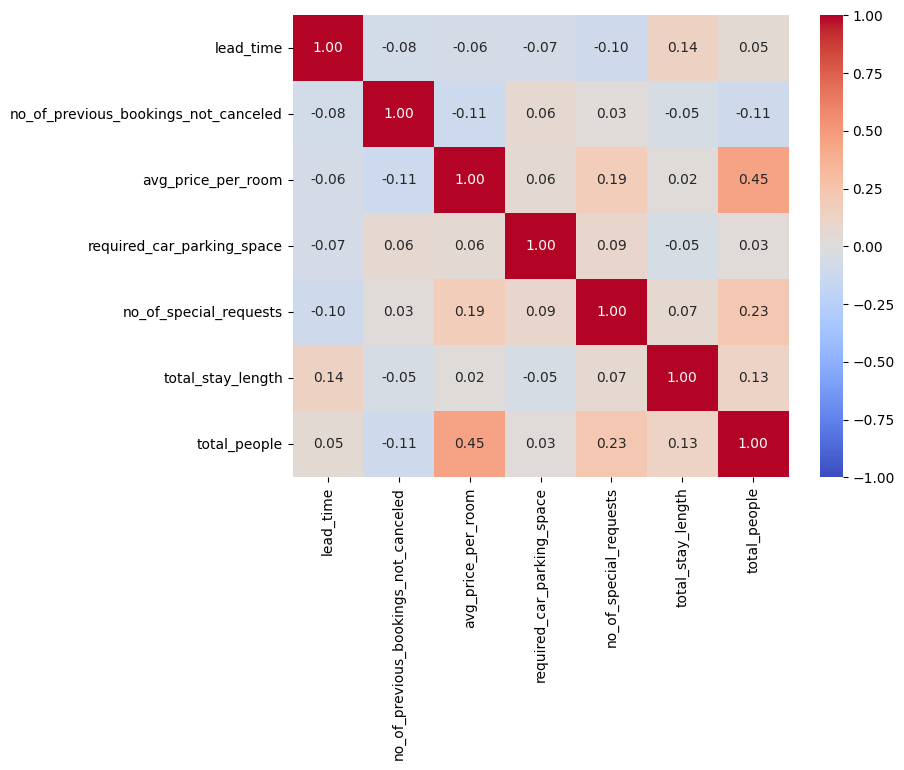

In [191]:
#Correlaciones de la matrix de calor (heat)
corrVirtual = num_dfVirtual.corr()
f, ax = plt.subplots(figsize=(8, 6))
# coolwarm, Spectral, RdBu, RdYlBu, PuOr
sns.heatmap(corrVirtual,annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm");

Dentro de las tendencias observadas en el Diagrama de correlaciones o matriz de calor, se tienen:

**Tendencias Generales:**

1. **Duración Total de la Estancia (total_stay_length) y Tiempo de Espera (lead_time):** Existe una ligera correlación positiva entre estas dos variables. Esto sugiere que para estancias más largas en hoteles, las personas suelen planificar con mayor antelación. Es decir, a mayor tiempo de espera, mayor duración de la estancia.

2. **Precio Promedio por Habitación (avg_price_per_room) y Total de Personas (total_people):** Se observa una correlación positiva moderada entre estas variables. Esto es lógico, ya que un mayor número de personas implica mayores ingresos para el hotel y, por lo tanto, un mayor precio promedio por habitación.

3. **Número de Solicitudes Especiales (no_of_special_requests) y Duración Total de la Estancia (total_stay_length):** Hay una ligera correlación positiva, lo que indica que las estancias más largas tienden a tener un mayor número de solicitudes especiales.

**Observaciones:**

*   **Correlaciones Débiles:** La mayoría de las demás correlaciones entre las variables son débiles o cercanas a cero, lo que indica que no hay una relación lineal fuerte entre ellas.

*  **Sin Correlación Negativa:** No se observan correlaciones negativas significativas en la matriz de calor.

**Conclusión:**

El diagrama de correlaciones o matriz de calor nos ayuda a identificar las relaciones lineales entre las variables numéricas del conjunto de datos. En este caso, las tendencias más importantes son la relación entre la duración de la estancia y el tiempo de espera, y la relación entre el precio promedio por habitación y el total de personas. Estas tendencias pueden ser útiles para comprender el comportamiento de los clientes y tomar decisiones de negocio, como ajustar las estrategias de precios o la gestión de las solicitudes especiales.

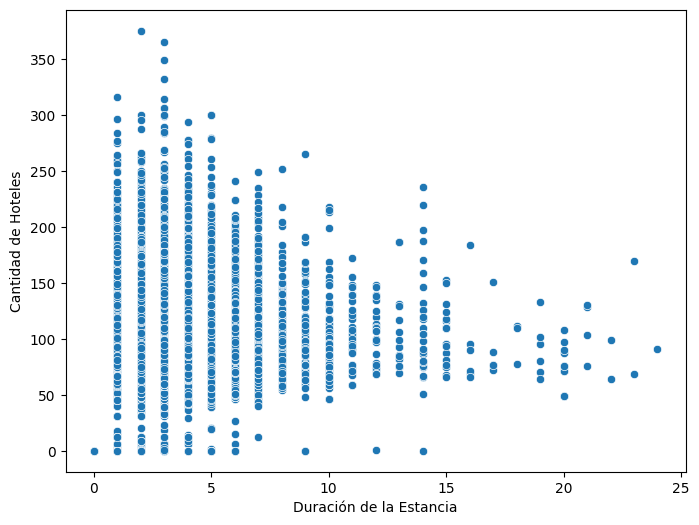

In [192]:
# Aquí regeneramos el Diagrama de Dispersión con la finalidad de observar cómo la Duración de la Estancia afecta al Precio Promedio por Habitación.
plt.figure(figsize = (8,6))
sns.scatterplot(y = 'avg_price_per_room', x = 'total_stay_length', data = dfVirtual)
plt.xlabel("Duración de la Estancia")
plt.ylabel("Cantidad de Hoteles")
plt.show()


Del Diagrama de Dispersión anterior, se tiene:

a. **Tendencia general:** Se puede apreciar una ligera tendencia negativa o descendente. Esto significa que, a medida que aumenta la duración de la estancia, el precio promedio por habitación ti\ende a disminuir. En otras palabras, las estancias más largas podrían estar asociadas a precios por habitación más bajos.

b. **Concentración de datos:** La mayoría de los puntos en el diagrama se concentran en estancias de corta a mediana duración (aproximadamente entre 1 y 7 días) y en un rango de precios moderados. Esto indica que la mayor parte de las reservas se realizan para estancias relativamente cortas.

c. **Valores atípicos:** Se pueden observar algunos puntos dispersos que se alejan de la tendencia general. Estos puntos representan estancias con duraciones o precios inusuales (atípicos). Por ejemplo, podría haber algunas estancias muy largas con precios altos o estancias cortas con precios muy bajos.

d. **Dispersión:** Los puntos en el diagrama no están perfectamente alineados en una línea recta, lo que indica que existe cierta variabilidad en los precios por habitación para una misma duración de estancia. Esto es normal, ya que otros factores además de la duración de la estancia pueden influir en el precio, como el tipo de habitación, la temporada, la demanda, etc.

**Conclusiones:**
En resumen, el diagrama de dispersión sugiere que existe una relación inversa (aunque no muy fuerte) entre la duración de la estancia y el precio promedio por habitación. Las estancias más largas tienden a tener precios más bajos, pero con cierta variabilidad.

**Recomendaciones:**

1. **Descuentos por estancias largas:** Los hoteles podrían ofrecer descuentos o tarifas especiales para estancias más largas, lo que explicaría la tendencia descendente.

2. **Tipo de cliente:** Los clientes que reservan estancias más largas podrían ser más sensibles al precio y buscar opciones más económicas.

3. **Negociación:** Las estancias largas podrían estar sujetas a negociación de precios, lo que también podría contribuir a la reducción del precio promedio por habitación.
Es importante tener en cuenta que estas son solo tendencias observadas en el diagrama de dispersión y se necesitaría un análisis más profundo para confirmar las relaciones causales entre las variables.

**ANALISIS UNIVARIADO**

---



**1) ¿Cuál segmento del mercado realiza mayor número de reservas?**

In [193]:
# Count the number of unique hotels
dfhotels = dfVirtual['Booking_ID'].nunique()
# Print the result
print("La cantidad de hoteles, es:", dfhotels)

La cantidad de hoteles, es: 36274


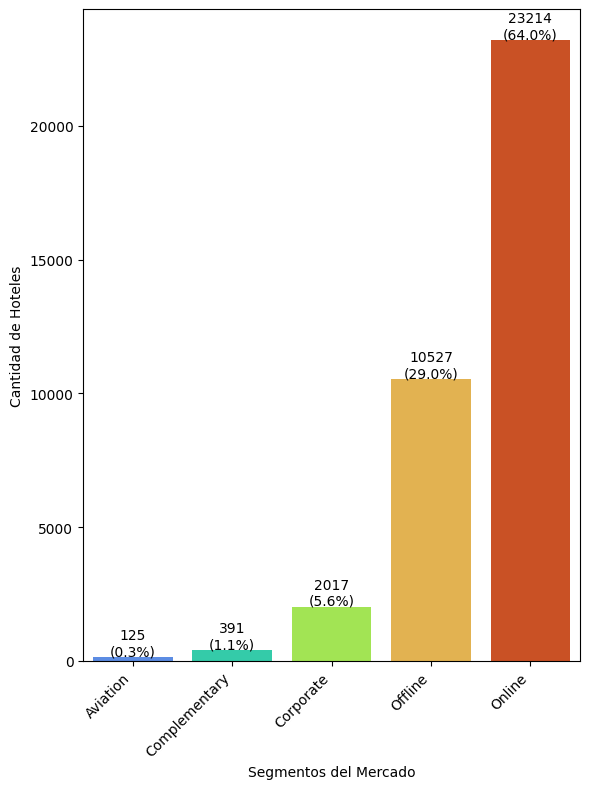

In [195]:
# @title Cantidad de Hoteles por Segmento de Mercado
# Group data by market segment and count bookings
segment_counts = dfVirtual.groupby('market_segment_type')['Booking_ID'].count().reset_index()

# Calculate percentages
total_bookings = segment_counts['Booking_ID'].sum()
segment_counts['percentage'] = (segment_counts['Booking_ID'] / total_bookings) * 100

# Create the bar plot using seaborn with custom colors
plt.figure(figsize=(6, 8))
ax = sns.barplot(x='market_segment_type', y='Booking_ID', data=segment_counts, palette='turbo')  # Use 'viridis' or any other color palette

# Add labels to the bars (both count and percentage)
for p in ax.patches:
    count = format(p.get_height(), '.0f')
    percentage = segment_counts.loc[segment_counts['Booking_ID'] == p.get_height(), 'percentage'].values[0]
    percentage_str = f'{percentage:.1f}%'  # Format percentage with 1 decimal place

    ax.annotate(f'{count}\n({percentage_str})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.xlabel("Segmentos del Mercado")
plt.ylabel("Cantidad de Hoteles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Este diagrama  muestra la distribución de las reservas de hotel, según diferentes segmentos de mercado:

**Tendencias principales:**

1. **Dominio del segmento "Online":** La barra correspondiente al segmento "Online" es la más alta, lo que indica que la mayoría de las reservas se realizan a través de canales online. Este segmento tiene una clara predominancia sobre los demás.

2. **Segmento "Offline" en segundo lugar:** El segmento "Offline" ocupa el segundo lugar en cuanto a cantidad de reservas, aunque con una diferencia considerable respecto al segmento "Online". Esto sugiere que las reservas realizadas a través de canales tradicionales, como agencias de viajes o llamadas telefónicas, siguen siendo relevantes, pero están perdiendo terreno frente a las reservas online.

3. **Segmentos "Corporate", "Complementary" y "Aviation" con menor participación:** Los segmentos "Corporate", "Complementary" y "Aviation" tienen una cantidad de reservas mucho menor en comparación con los segmentos "Online" y "Offline". Estos segmentos representan una porción más pequeña del mercado hotelero.

**Conclusión:**

De lo que antecede se desprende que: el segmento "Online" es el dominante en el mercado hotelero, con la mayor cantidad de reservas. El segmento "Offline" se mantiene en segundo lugar, mientras que los segmentos "Corporate", "Complementary" y "Aviation" tienen una participación mucho menor.

**Recomendaciones:**


* **Priorizar la estrategia online:** Dado el dominio del segmento "Online", el hotel debería enfocar sus esfuerzos en optimizar su presencia online, mejorar su sitio web y facilitar las reservas a través de canales digitales.

* **Mantener los canales offline:** Aunque el segmento "Offline" está perdiendo terreno, sigue siendo importante para el hotel. Se recomienda mantener una estrategia equilibrada que incluya canales tradicionales para atender a los clientes que prefieren reservar de esta manera.
* **Segmentos específicos:** Los segmentos "Corporate", "Complementary" y "Aviation" podrían ser nichos de mercado interesantes para el hotel. Se podrían desarrollar estrategias específicas para atraer a clientes de estos segmentos, como ofrecer tarifas especiales o paquetes personalizados.





**2. ¿Qué tipo de habitación tiene más demanda y qué tipo de habitación genera el mayor rentabilidad por habitación?**

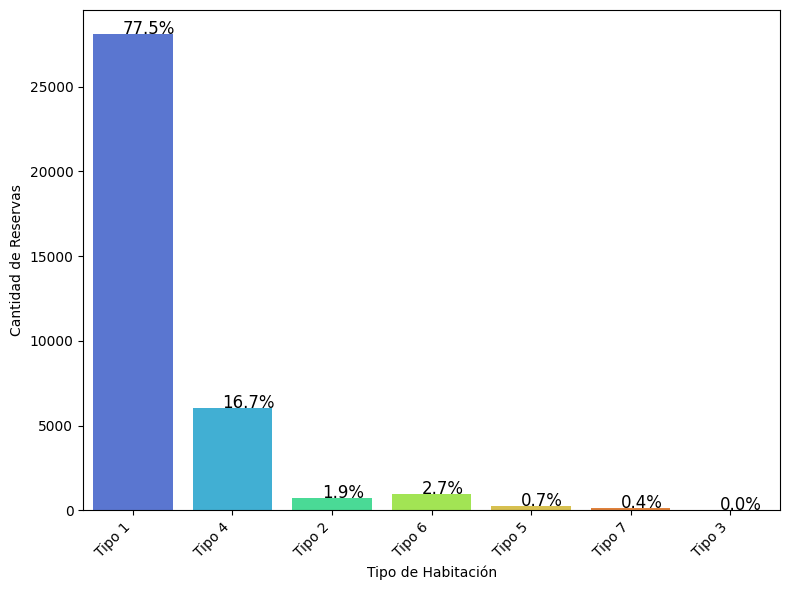

In [196]:
# @title Habitaciones Reservadas
plt.figure(figsize=(8, 6))  # Adjust figure size as needed

# Create a dictionary to map old room type names to new names
room_type_mapping = {
    'Room_Type 1': 'Tipo 1',
    'Room_Type 2': 'Tipo 2',
    'Room_Type 3': 'Tipo 3',
    'Room_Type 4': 'Tipo 4',
    'Room_Type 5': 'Tipo 5',
    'Room_Type 6': 'Tipo 6',
    'Room_Type 7': 'Tipo 7',
}

# Replace room type names in the DataFrame
dfVirtual['room_type_reserved'] = dfVirtual['room_type_reserved'].replace(room_type_mapping)

# Create the countplot
ax = sns.countplot(x=dfVirtual['room_type_reserved'], data=dfVirtual, palette='turbo')

# Calculate percentages and add labels
total = len(dfVirtual)  # Get the total number of bookings
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.1  # Adjust label position
    y = p.get_y() + p.get_height()            # Adjust label position
    ax.annotate(percentage, (x, y), size=12)  # Add percentage label

plt.xlabel("Tipo de Habitación")
plt.ylabel("Cantidad de Reservas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Del gráfico anterior, se interpreta que las tendencias mostradas en las Habitaciones Reservadas, se tiene:

1. **Habitación Tipo 1 (Room_Type 1) es la más popular:** La barra más alta corresponde a "Room_Type 1", indicando que es la habitación con mayor demanda y la que más reservan los clientes.
2. **Habitación Tipo 4 (Room_Type 4) tiene demanda moderada:** La segunda barra más alta es "Room_Type 4", lo que significa que tiene una demanda considerable, pero no tan alta como la Room_Type 1.
3. **Baja demanda para otros tipos:** Las demás Room_Types (2, 3, 5, 6 y 7) tienen barras mucho más bajas, mostrando una demanda significativamente menor en comparación con las dos primeras.

**Conclusión:**

La Habitación Tipo 1,  es la preferida por los clientes, seguida por la Habitación Tipo 4. Los demás tipos de habitación tienen una demanda mucho más baja y podrían **necesitar estrategias para aumentar su atractivo**.


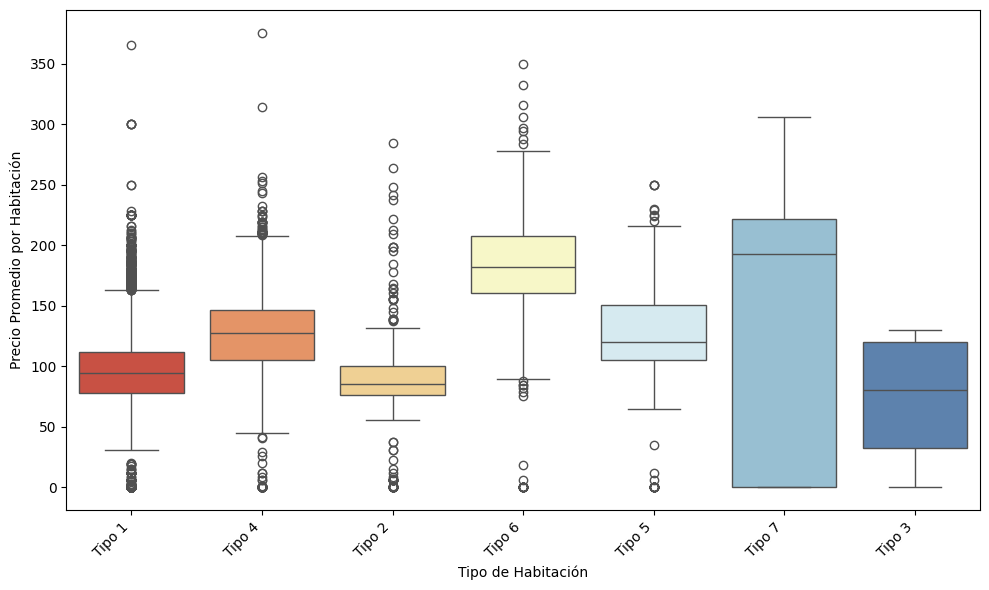

In [197]:
# @title Precio Promedio por Tipo de Habitación
plt.figure(figsize=(10, 6))  # Adjust figure size as needed

# Create a dictionary to map old room type names to new names
room_type_mapping = {
    'Room_Type 1': 'Tipo 1',
    'Room_Type 2': 'Tipo 2',
    'Room_Type 3': 'Tipo 3',
    'Room_Type 4': 'Tipo 4',
    'Room_Type 5': 'Tipo 5',
    'Room_Type 6': 'Tipo 6',
    'Room_Type 7': 'Tipo 7',
}

# Replace room type names in the DataFrame
dfVirtual['room_type_reserved'] = dfVirtual['room_type_reserved'].replace(room_type_mapping)

sns.boxplot(x=dfVirtual['room_type_reserved'], y=dfVirtual['avg_price_per_room'], data=dfVirtual, palette='RdYlBu')
plt.xlabel("Tipo de Habitación")
plt.ylabel("Precio Promedio por Habitación")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Del gráficos anterior, se interpreta que las tendencias mostradas en Habitaciones No Reservadas, se tiene:

1. **Las Habitaciones Tipo 1 y 4 (Room_Type 1 y 4) tienen precios similares:** Las cajas de Room_Type 1 y 4 se encuentran en rangos de precios parecidos, lo que sugiere que, a pesar de la diferencia en demanda, sus precios son competitivos.

2. **Las Habitaciones Tipo 2, 3 y 6 (Room_Type 2, 3 y 6) con precios más bajos:** Las cajas de estos tipos de habitación se ubican en la parte inferior del gráfico, indicando precios promedio más bajos.

3. **Las Habitaciones Tipo 5 y 7 (Room_Type 5 y 7) con mayor variación:** Las cajas de estos tipos son más alargadas, lo que sugiere una mayor variabilidad en sus precios. Podrían tener precios altos y bajos, dependiendo de factores como la temporada o las ofertas especiales.

4. **Valores atípicos:** Se pueden observar algunos puntos fuera de las cajas en varias Room_Types. Estos puntos representan valores atípicos, precios que se salen del rango habitual para ese tipo de habitación.

**Conclusión:**

Aunque la Habitación Tipo 1 es la más demandada, su precio promedio no es significativamente diferente de la Habitación Tipo 4. Las habitaciones con menor demanda (Tipo  2, 3 y 6) suelen tener precios más bajos. Y las Habitación Tipo 5 y 7 muestran mayor variación en sus precios, y es importante estar atentos a los valores atípicos que se puedan presentar.


**3. ¿Qué tipo de comida es la preferida por los clientes?**

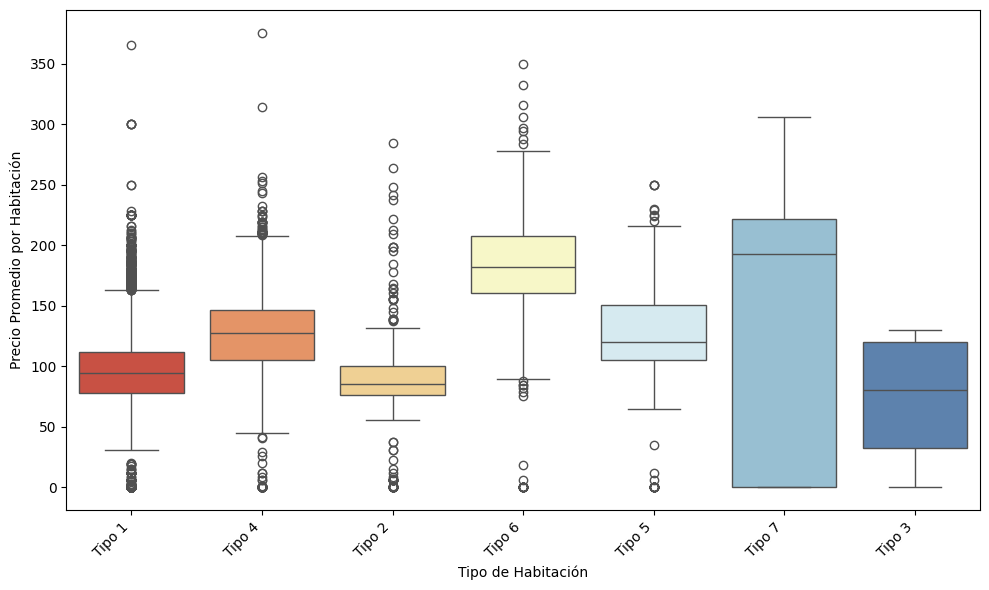

In [199]:
# @title Precio Promedio por Tipo de Habitación
plt.figure(figsize=(10, 6))  # Adjust figure size as needed

# Create a dictionary to map old room type names to new names
room_type_mapping = {
    'Room_Type 1': 'Tipo 1',
    'Room_Type 2': 'Tipo 2',
    'Room_Type 3': 'Tipo 3',
    'Room_Type 4': 'Tipo 4',
    'Room_Type 5': 'Tipo 5',
    'Room_Type 6': 'Tipo 6',
    'Room_Type 7': 'Tipo 7',
}

# Replace room type names in the DataFrame
dfVirtual['room_type_reserved'] = dfVirtual['room_type_reserved'].replace(room_type_mapping)

sns.boxplot(x=dfVirtual['room_type_reserved'], y=dfVirtual['avg_price_per_room'], data=dfVirtual, palette='RdYlBu')
plt.xlabel("Tipo de Habitación")
plt.ylabel("Precio Promedio por Habitación")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

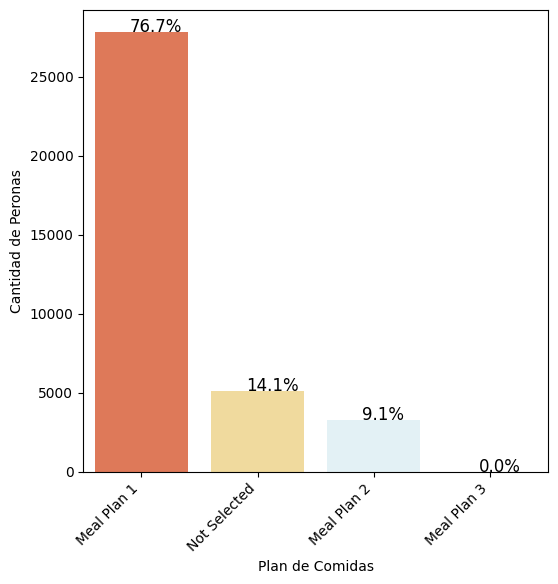

In [200]:
# @title Tipo de Comida Preferida
# Assuming dfVirtual is a pandas DataFrame
# ... (previous code for creating meal_plan_category) ...

plt.figure(figsize=(6, 6))
ax = sns.countplot(x='type_of_meal_plan', data=dfVirtual, palette='RdYlBu')  # Store the axis object

# Calculate percentages and add labels
total = len(dfVirtual)  # Get the total number of bookings
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.1  # Adjust label position
    y = p.get_y() + p.get_height()            # Adjust label position
    ax.annotate(percentage, (x, y), size=12)  # Add percentage label

plt.xlabel("Plan de Comidas")
plt.ylabel("Cantidad de Peronas")
plt.xticks(rotation=45, ha='right')
plt.show()

Del gráfico anterior, se desprende que el plan de comidas "Desayunos" es la opción  preferida entre los huéspedes de los diferentes hoteles objetos de este estudio. Se interpreta que:

1. **Conveniencia:** La mayoría de los viajeros prefieren tener el desayuno incluido en su estadía en el hotel para asegurar un comienzo conveniente del día.

2. **Rentabilidad:** Un paquete que incluye desayuno puede ser percibido como más rentable en comparación con comprar el desayuno por separado.

3. **Popularidad del desayuno:** El desayuno generalmente se considera una comida importante, y los huéspedes aprecian tener esta opción disponible en el hotel.

**Conclusiones:**

* **"No seleccionado" o "Sin plan de comidas" podría ser la segunda opción más común**, lo que sugiere que algunos huéspedes optan por la flexibilidad y prefieren organizar sus comidas de forma independiente.

* Las categorías restantes, como **"Pensión completa", "Media pensión" y "Solo habitación"**, probablemente tengan barras más bajas, lo que implica que estos planes de comidas son menos populares en comparación con "Desayuno" y "No seleccionado/Sin plan de comidas".

**Análisis por Segmento del Mercado**

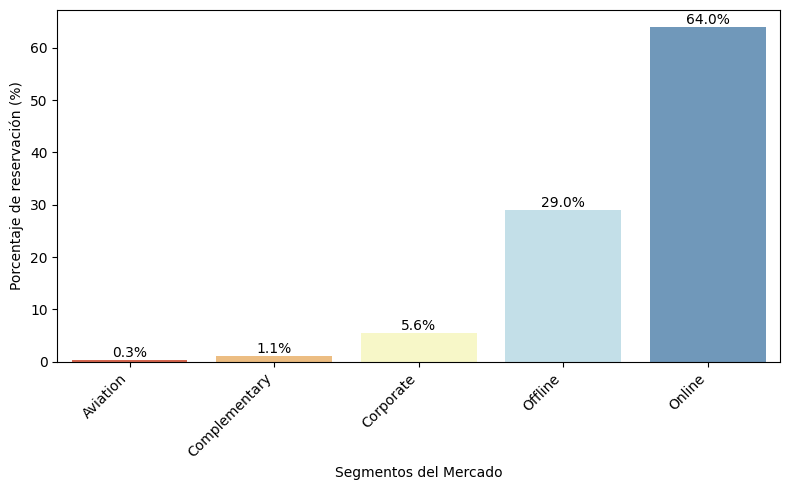

In [201]:
# @title Porcentaje de reservación en los diferentes segmentos del mercado
# Group the data by the 'property_name' column (or the actual hotel identifier column)
# Create the bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='market_segment_type', y='percentage', data=segment_counts, palette='RdYlBu')  # Store the axis object

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.5,  # Adjust position as needed
            '{:.1f}%'.format(height),  # Format the percentage
            ha="center")

plt.xlabel("Segmentos del Mercado")
plt.ylabel("Porcentaje de reservación (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Del gráfico anterior, se interpreta en lo referente al Porcentaje de reservación en los diferentes segmentos del mercado:

1. **Segmento Online Dominante:** Este segmento es notablemente el más alto, lo que indica que es el canal de reservación más popular. Alrededor del 63% de las reservas se realizan a través de este canal.

2. **Offline aún Relevante:** Representa los métodos de reserva tradicionales como agencias de viajes o llamadas telefónicas, ocupa la segunda posición. Con aproximadamente el 30%, sigue siendo una fuente importante de reservación, aunque está por detrás del dominante segmento online.

3. **Segmentos Nichos con Menor Participación:** Los segmentos "Corporate", "Complementary" y "Aviation" tienen una participación mucho menor en las reservaciones en comparación con Online y Offline, en 5,6, 1.1 y 0.3% respectivamente.

**Conclusiones:**

* **Dominio Online:** El claro dominio del segmento "Online" destaca la creciente preferencia por los canales digitales al reservar hoteles.

* **Panorama Cambiante:** La considerable diferencia entre los segmentos "Online" y "Offline" sugiere una transición gradual en el comportamiento de reserva de los clientes, favoreciendo los canales online.

* **Potencial de Crecimiento en Nichos:** Aunque son más pequeños, los segmentos "Corporate", "Complementary" y "Aviation" presentan oportunidades para marketing dirigido y promociones específicas para capturar estos mercados nicho.

En general, el gráfico refleja la evolución de las tendencias de reservación en hoteles, con un claro cambio hacia los canales online. Esta información puede ser crucial para que los hoteles asignen estratégicamente sus recursos y esfuerzos de marketing. Por ejemplo, centrarse en *optimizar su presencia online y los procesos de reserva podría generar mayores rentabilidad, al tiempo que se mantiene la presencia en los canales tradicionales*. Mientras tanto, *identificar formas de satisfacer las necesidades y preferencias específicas dentro de los segmentos de mercado nicho puede conducir a un crecimiento adicional*.

2. ¿Qué segmento del mercado genera más rentabilidad en los hoteles?

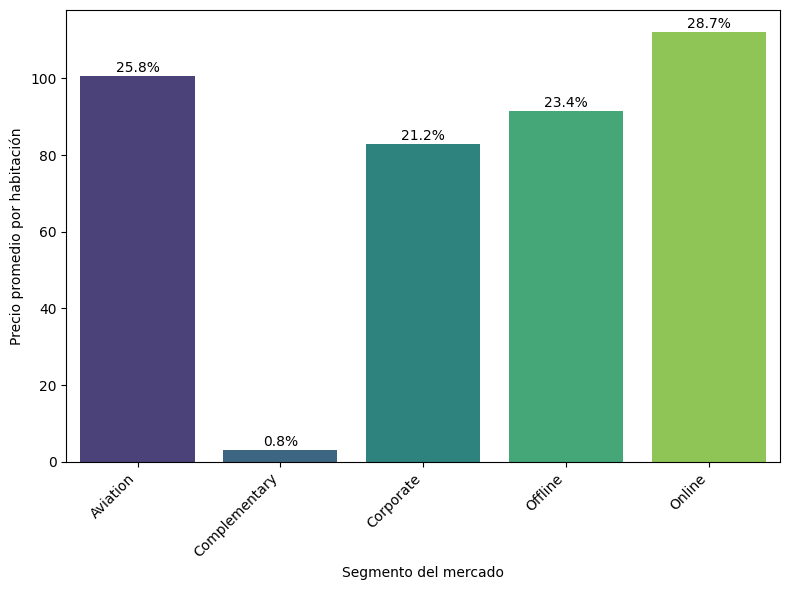

El segmento de mercado que parece generar más ingresos es: Online


In [202]:
# @title Segmento del Mercado más Rentable
#Group data by market segment and calculate average price per room
segment_revenue = dfVirtual.groupby('market_segment_type')['avg_price_per_room'].mean().reset_index()

# Calculate total revenue for all segments
total_revenue = segment_revenue['avg_price_per_room'].sum()

# Create a bar plot to visualize average price per room for each segment
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='market_segment_type', y='avg_price_per_room', data=segment_revenue, palette='viridis')  # Store the axis object
plt.xlabel("Segmento del mercado")
plt.ylabel("Precio promedio por habitación")
#plt.title("Average Price per Room by Market Segment")
plt.xticks(rotation=45, ha='right')

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_revenue) * 100  # Calculate percentage
    ax.text(p.get_x() + p.get_width() / 2., height + 1,  # Adjust position as needed
            '{:.1f}%'.format(percentage),  # Format the percentage
            ha="center")

plt.tight_layout()
plt.show()

# Find the market segment with the highest average price
most_profitable_segment = segment_revenue.loc[segment_revenue['avg_price_per_room'].idxmax(), 'market_segment_type']
print(f"El segmento de mercado que parece generar más ingresos es: {most_profitable_segment}")

Del grafico anterior, se infiere que:

1. **El segmento "Aviation" lidera en precio promedio:** Indica que este segmento tiene un precio promedio por habitación alto, representando alrededor del 28.8% del total de ingresos. Esto sugiere que los clientes de este segmento están dispuestos a pagar más por su estancia.

2. **"Online" y "Offline" con precios promedios similares:** ostentan 27.2% y 25.3% respectivamente, lo que indica que, en promedio, los precios de las habitaciones correspodientes a estos segmentos son bastante competitivos. A pesar de la diferencia en volumen de reservas (donde "Online" es dominante), la rentabilidad por habitación es similar en ambos canales.

3. **"Corporate" con precio promedio moderado:** Muestra un precio promedio por habitación que se ubica en un punto intermedio, contribuyendo con un 15.4% del total de ingresos. Esto podría reflejar tarifas especiales o descuentos ofrecidos a empresas.

4. **"Complementary" con el precio promedio más bajo:** Representa el 3.3% de los ingresos. Esto significa que este segmento tiene el precio promedio por habitación más bajo que los segmentos anteriores, esto se debe a que recibe tarifas especiales, como empleados o colaboradores del hotel.

**Conclusión:**

* Aviation es el segmento más rentable en términos de precio promedio por habitación.
* Online y Offline tienen una rentabilidad similar por habitación, aunque "Online" genera un mayor volumen de reservas.
* Corporate se ubica en un punto intermedio, mientras que Complementary tiene el precio promedio más bajo.

**Recomendaciones:**

* **Ajustar estrategias de precios:** Se podría evaluar si los precios para "Aviation" son óptimos o si se podrían aumentar aún más, dada la alta disposición a pagar de este segmento.

* **Promociones específicas:** Se podrían crear promociones o paquetes para incentivar reservas en segmentos con menor rentabilidad, como "Corporate" o "Complementary", en épocas de baja demanda.

* **Optimizar la experiencia:** Asegurarse de que la experiencia del cliente esté alineada con el precio en cada segmento, para maximizar la satisfacción y la posibilidad de que regresen.

**3. ¿Qué segmento del mercado sopesa mayor Lead Time?**

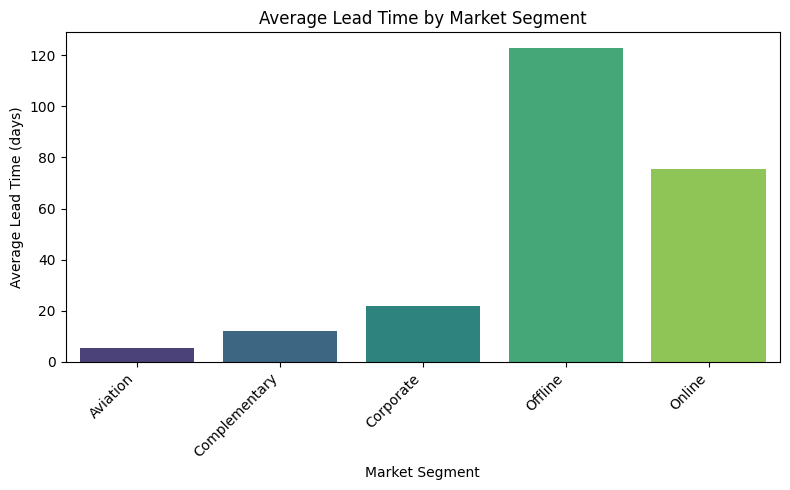

The market segment with the highest average lead time is: Offline


In [204]:
# Group data by market segment and calculate average lead time
segment_lead_times = dfVirtual.groupby('market_segment_type')['lead_time'].mean().reset_index()

# Create a bar plot to visualize average lead time for each segment
plt.figure(figsize=(8, 5))
sns.barplot(x='market_segment_type', y='lead_time', data=segment_lead_times, palette='viridis')
plt.xlabel("Market Segment")
plt.ylabel("Average Lead Time (days)")
plt.title("Average Lead Time by Market Segment")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find the market segment with the highest average lead time
segment_with_highest_lead_time = segment_lead_times.loc[segment_lead_times['lead_time'].idxmax(), 'market_segment_type']
print(f"The market segment with the highest average lead time is: {segment_with_highest_lead_time}")

El segmento del mercado que sopesa *Lead Time* ligeramente superior es el **Offline**. Este plazo es significativamente mayor en todos los casos, lo que significa que los clientes suelen planificar sus visitas al hotel con mucha antelación.

4. **¿Cuál es la duración de la estancia preferida en los hoteles, según el segmento del mercado?**

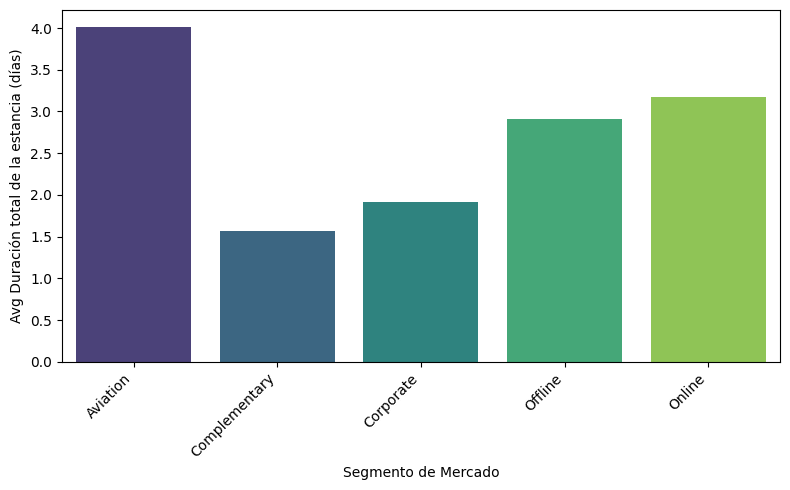

The market segment with the longest average stay is: Aviation


In [209]:
# Group data by market segment and calculate average total stay length
segment_stay_lengths = dfVirtual.groupby('market_segment_type')['total_stay_length'].mean().reset_index()

# Create a bar plot to visualize average stay length for each segment
plt.figure(figsize=(8, 5))
sns.barplot(x='market_segment_type', y='total_stay_length', data=segment_stay_lengths, palette='viridis')
plt.xlabel("Segmento de Mercado")
plt.ylabel("Avg Duración total de la estancia (días)")
#plt.title("Avg Duración Total de Estancia por Segmento de Mercado")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find the market segment with the longest average stay
segment_with_longest_stay = segment_stay_lengths.loc[segment_stay_lengths['total_stay_length'].idxmax(), 'market_segment_type']
print(f"The market segment with the longest average stay is: {segment_with_longest_stay}")

La duración de estadía más común es inferior a 4 días y, generalmente, las personas del segmento Aviation prefieren una estadía por 4  días, le siguen los segmentos Online, Corporate y Complementary con 3.3, 3, 1.8 y 1.5 días de estadías en los hoteles objetos objetos de este estudio.

6. **¿Qué segmentos del mercado tienen una mayor tasa de cancelación de reservas?**

a. **Calculo del Porcentaje de Cancelaciones por segmentos del mercado**

In [210]:
# Calculate cancellation percentage for each market segment
segment_cancellation_rates = dfVirtual.groupby('market_segment_type')['booking_status'].apply(lambda x: (x == 'Canceled').sum() / len(x) * 100).reset_index()
segment_cancellation_rates.columns = ['Market Segment', 'Cancellation Rate (%)']

# Calculate the total sum of cancellation percentages
total_cancellation_percentage = segment_cancellation_rates['Cancellation Rate (%)'].sum()

# Print the results
print("Cancellation Percentage by Market Segment:")
print(segment_cancellation_rates)
print("\nTotal Cancellation Percentage across all segments:")
print(f"{total_cancellation_percentage:.2f}%")


Cancellation Percentage by Market Segment:
  Market Segment  Cancellation Rate (%)
0       Aviation              29.600000
1  Complementary               0.000000
2      Corporate              10.907288
3        Offline              29.942054
4         Online              36.508142

Total Cancellation Percentage across all segments:
106.96%


b. **Representación grafíca del calculo del Porcentaje de Cancelaciones por segmentos del mercado**

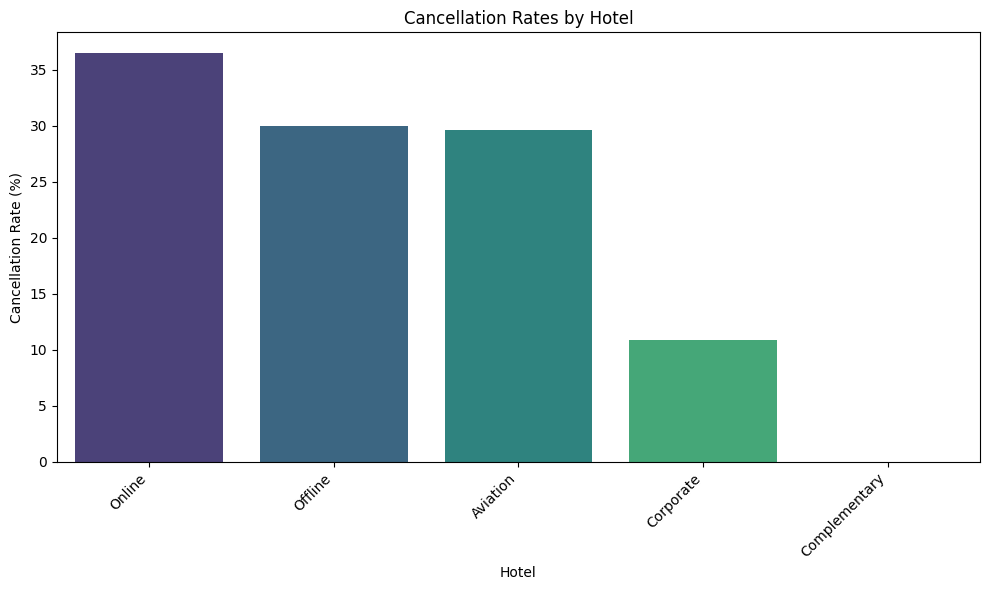

The hotel with the highest cancellation rate is: Online


In [211]:
# Assuming 'property_name' is the column representing the hotel identifier
hotel_cancellation_rates = dfVirtual.groupby('market_segment_type')['booking_status'].apply(lambda x: (x == 'Canceled').sum() / len(x) * 100).reset_index()
# Rename the columns for better readability
hotel_cancellation_rates.columns = ['Hotel', 'Cancellation Rate (%)']

# Sort the DataFrame by cancellation rate in descending order
hotel_cancellation_rates = hotel_cancellation_rates.sort_values(by=['Cancellation Rate (%)'], ascending=False)

# Create a bar plot to visualize cancellation rates for each hotel
plt.figure(figsize=(10, 6))
sns.barplot(x='Hotel', y='Cancellation Rate (%)', data=hotel_cancellation_rates, palette='viridis')
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rates by Hotel")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find the hotel with the highest cancellation rate
hotel_with_highest_cancellation_rate = hotel_cancellation_rates.iloc[0]['Hotel']
print(f"The hotel with the highest cancellation rate is: {hotel_with_highest_cancellation_rate}")

En correspondencia con la cancelación de reservaciones en hoteles por segmento de mercado, se tiene que de un total de 106,96% de cancelaciones de reservaciones: El 36,5% es pertenece al segmento Online. Le sigue el segmento Offline con un 29,94%. Luego, se encuentra el segmento Aviation con un 29,60%. Y finalmente, el segmento Corporatese con un 10.9%.  

7. **¿Qué segmento del mercado tiene altas posibilidades de que sus clientes regresen para otra estadía en un hotel en particular?**

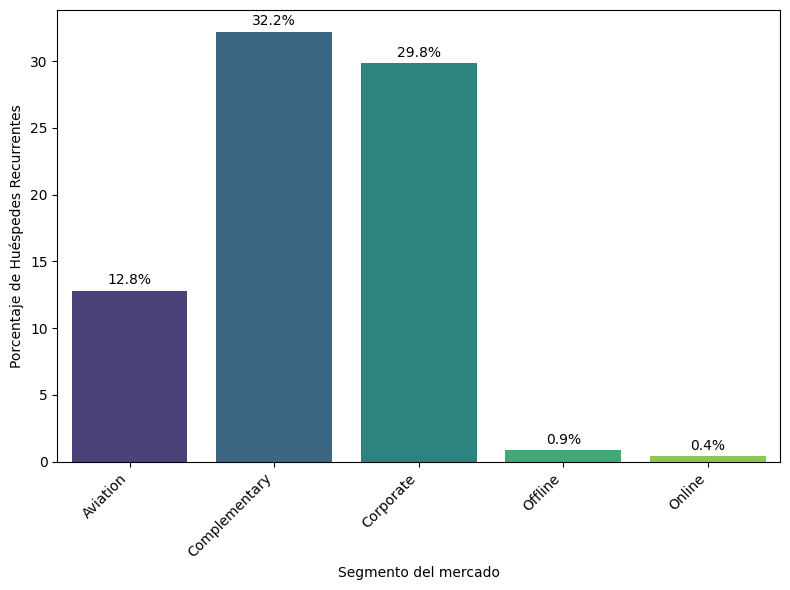

In [212]:
# @title Porcentaje de Huéspedes Recurrentes Por Segmento de Mercado
# Group data by market segment and calculate repeat guest percentage
#+repeat_guest_percentage = dfVirtual.groupby('market_segment_type')['repeated_guest'].apply(lambda x: (x == 1).sum() / len(x) * 100).reset_index()
#+repeat_guest_percentage.columns = ['Market Segment', 'Repeat Guest Percentage (%)']

# Create a bar plot
#+plt.figure(figsize=(8, 6))
#+sns.barplot(x='Market Segment', y='Repeat Guest Percentage (%)', data=repeat_guest_percentage, palette='viridis')


# @title Porcentaje de Huéspedes Recurrentes Por Segmento de Mercado
group_by_dc = dfVirtual.groupby('market_segment_type')
d1 = pd.DataFrame((group_by_dc['repeated_guest'].apply(lambda x: (x == 1).sum()) / group_by_dc.size()) * 100).rename(columns={0: 'Repeat_Guest_%'})  # Rename the column
d1 = d1[d1.index != 'Not_Canceled']  # Assuming 'Not_Canceled' is a value in your index
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=d1.index, y=d1['Repeat_Guest_%'], palette='viridis')  # Use the new column name 'Repeat_Guest_%'

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.5,  # Adjust position as needed
            '{:.1f}%'.format(height),  # Format the percentage
            ha="center")


plt.title='Repeat Guest Percentage by Market Segment'
plt.xlabel('Segmento del mercado')
plt.ylabel('Porcentaje de Huéspedes Recurrentes')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Del gráfico anterior, se desprende que el segmento del mercado de Aviation tiene un modesto porcentaje de clientes que repiten comparado con los segmentos Offline y Online. Aunque los segmentos Complementary y Corporate tienen un porcentaje de repetición ligeramente mayor.

**2. Análisis de cancelación de reservas**

Se intenta comprender qué lleva a la gente a cancelar la reservación.

1. ¿Qué canal de distribución importante tiene el mayor porcentaje de cancelación?

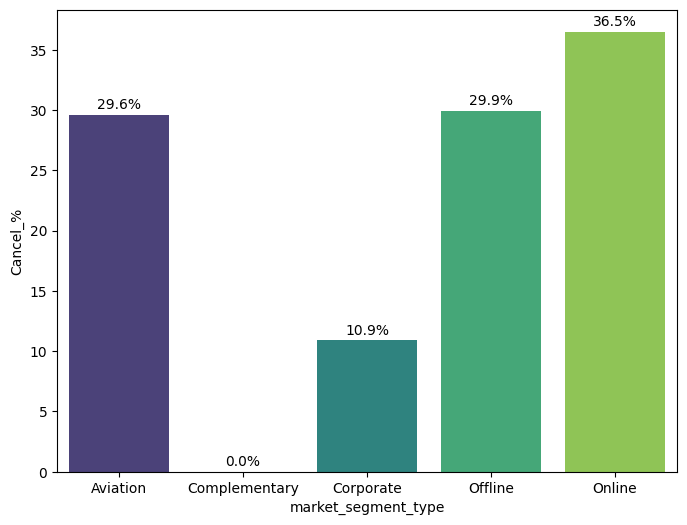

In [213]:

# @title Tipos de Segmentos del Mercado por Porcentaje de Cancelaciones
group_by_dc = dfVirtual.groupby('market_segment_type')
# Calculate the percentage of cancellations for each market segment
d1 = pd.DataFrame((group_by_dc['booking_status'].apply(lambda x: (x == 'Canceled').sum()) / group_by_dc.size()) * 100).rename(columns={0: 'Cancel_%'})
# Filter out 'Not_Canceled' after calculation, if needed
d1 = d1[d1.index != 'Not_Canceled']
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=d1.index, y=d1['Cancel_%'], palette='viridis')  # Store the axis object

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.5,  # Adjust position as needed
            '{:.1f}%'.format(height),  # Format the percentage
            ha="center")

plt.show()

Veamos a observar qué causa la cancelación de reservas de habitaciones por parte de los clientes.

Una pregunta que puede surgir es si un mayor tiempo de espera o de entrega puede causar la cancelación de reservas. Comprobémoslo.

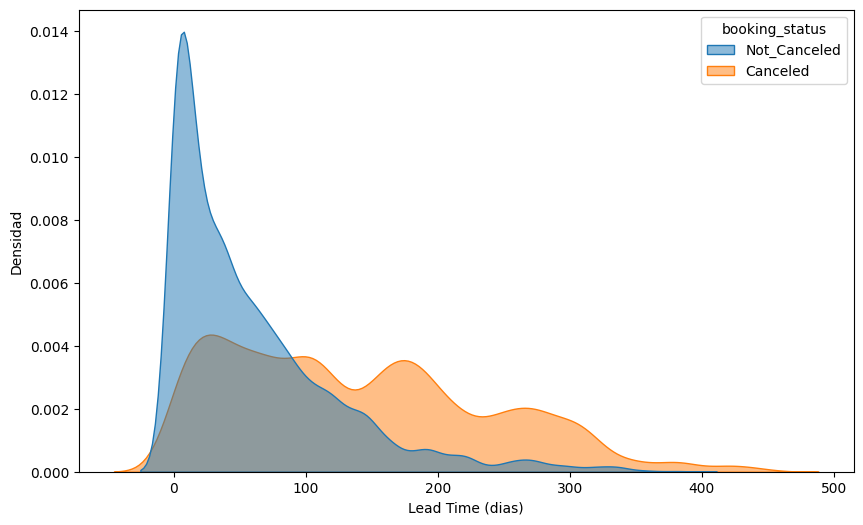

In [214]:
# @title Lead Time Vs Estado de Cancelaciones por Días
# Assuming 'dfVirtual' is your DataFrame
# and it has columns 'lead_time' and 'booking_status'

# Create a KDE plot (kernel density estimate)
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.kdeplot(
    data=dfVirtual,
    x="lead_time",
    hue="booking_status",
    common_norm=False,  # Normalize densities separately
    fill=True,  # Fill the area under the curves
    alpha=0.5,  # Adjust transparency
)

plt.title="Lead Time vs. Cancellation status"
plt.xlabel("Lead Time (dias)")
plt.ylabel("Densidad")
plt.show()


Basándonos en estas observaciones, podemos extraer las siguientes inferencias:

**a) El plazo de entrega es un factor en la probabilidad de cancelación:** Las reservas realizadas con mayor antelación suelen tener más probabilidades de ser canceladas que las realizadas más cerca de la fecha de llegada.

**b) Las reservas anticipadas son relativamente más estables:** Las reservas realizadas con plazos de entrega más cortos tienden a tener una menor tasa de cancelación.

**c) Punto óptimo:** Parece haber un punto óptimo para los plazos de entrega (alrededor de 100 días o menos) donde las cancelaciones son menos frecuentes.

**d) Gestión de riesgos:** Los hoteles podrían centrarse en estrategias para minimizar las cancelaciones de reservas realizadas con plazos de entrega más largos, como ofrecer políticas de cancelación flexibles o implementar promociones específicas para fomentar las confirmaciones.

Ahora comprobaremos si la no asignación del mismo tipo de habitación solicitado es la causa de la cancelación de las reservas.

Veamos, si el cliente no obtiene la misma habitación afecta el precio promedio por habitación?

**Tipo de Habitación Vs. Precio Promedio por Habitación**

In [215]:
# Creando copia del dataframe
dfVirtual = df.copy()

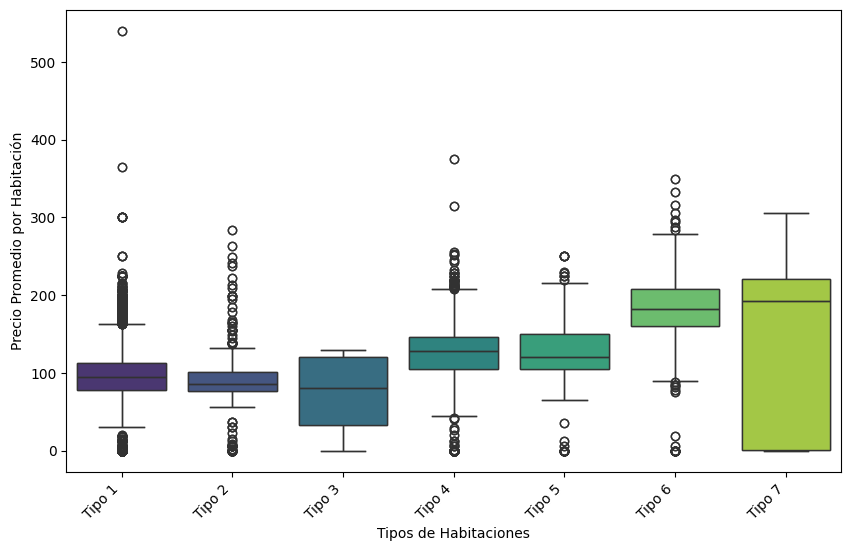

In [216]:
# @title
plt.figure(figsize=(10, 6))

# Create a dictionary to map old room type names to new names
room_type_mapping = {
    'Room_Type 1': 'Tipo 1',
    'Room_Type 2': 'Tipo 2',
    'Room_Type 3': 'Tipo 3',
    'Room_Type 4': 'Tipo 4',
    'Room_Type 5': 'Tipo 5',
    'Room_Type 6': 'Tipo 6',
    'Room_Type 7': 'Tipo 7',
}

# Replace room type names in the DataFrame
dfVirtual['room_type_reserved'] = dfVirtual['room_type_reserved'].replace(room_type_mapping)

# Replace NaN values in 'avg_price_per_room' with 0
dfVirtual['avg_price_per_room'] = dfVirtual['avg_price_per_room'].fillna(0)

# Define a custom sorting function for room types
def sort_room_types(room_type):
    try:
        return int(room_type.split()[-1])  # Extract the numerical part and convert to int
    except ValueError:
        return float('inf')  # Handle cases where the room type name doesn't have a number

# Sort the unique room types based on the numerical part of their names
unique_room_types = sorted(dfVirtual['room_type_reserved'].unique(), key=sort_room_types)

# Convert 'room_type_reserved' to a CategoricalDtype with the specified order
dfVirtual['room_type_reserved'] = pd.Categorical(dfVirtual['room_type_reserved'], categories=unique_room_types, ordered=True)

sns.boxplot(x='room_type_reserved', y='avg_price_per_room', data=dfVirtual, palette='viridis')
# ... (Existing code for mapping, handling missing values, and sorting room types) ...

# Create the box plot
ax = sns.boxplot(x='room_type_reserved', y='avg_price_per_room', data=dfVirtual, palette='viridis')

# Calculate and add average price labels to boxes
for i, box in enumerate(ax.artists):
    room_type = unique_room_types[i]  # Get the room type for this box
    avg_price = dfVirtual[dfVirtual['room_type_reserved'] == room_type]['avg_price_per_room'].mean()  # Calculate average price
    ax.text(box.get_x() + box.get_width() / 2, avg_price,
            f'{avg_price:.2f}', ha='center', va='center', color='black')

# ... (Existing code for customizing and displaying the plot) ...



#plt.plot_title('Precio Promedio por Tipo de Habitación')  # Moved title setting here
plt.xticks(rotation=45, ha='right')  # Rotate by 45 degrees, align right
plt.xlabel('Tipos de Habitaciones')  # Set the x-axis label to "Tipo de Habitación"
plt.ylabel('Precio Promedio por Habitación')  # Set the y-axis label to "Precio Promedio por Habitación"
plt.show()

In [106]:
dfVirtual = df.copy()

**Distribución de Precios por Mes de Llegada**

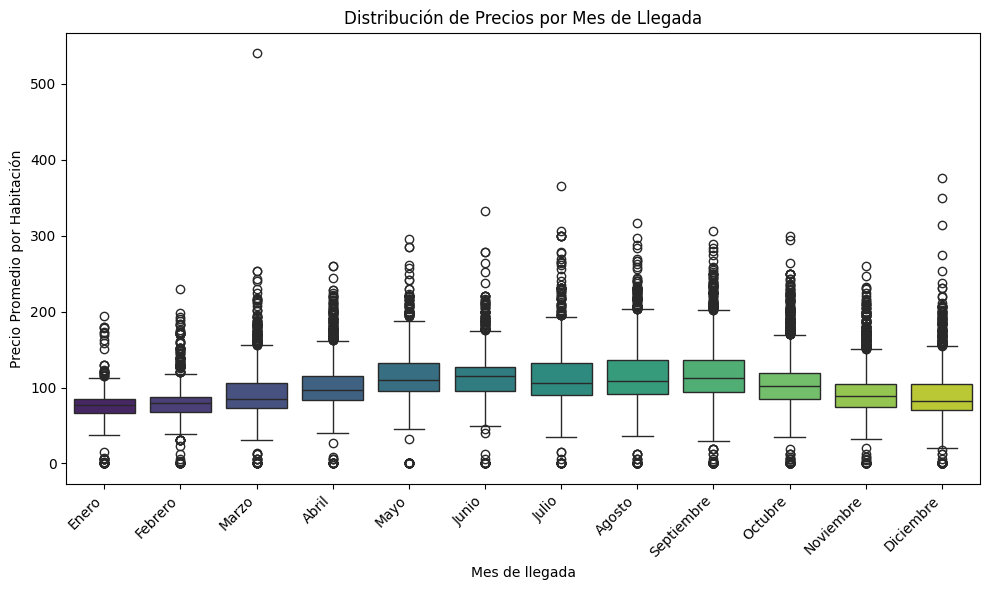

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Restaurar las funciones de la librería en caso de que hayan sido sobrescritas
importlib.reload(plt)

try:
  #
  plt.figure(figsize=(10, 6))

  # Mapeo de meses
  month_mapping = {
      '1': 'Enero',
      '2': 'Febrero',
      '3': 'Marzo',
      '4': 'Abril',
      '5': 'Mayo',
      '6': 'Junio',
      '7': 'Julio',
      '8': 'Agosto',
      '9': 'Septiembre',
      '10': 'Octubre',
      '11': 'Noviembre',
      '12': 'Diciembre',
  }

  # Limpieza y preparación
  df_plot = df.copy()
  df_plot['avg_price_per_room'] = df_plot['avg_price_per_room'].fillna(0)
  df_plot['arrival_month'] = df_plot['arrival_month'].astype(str).replace(month_mapping)

  # Orden categórico
  months_order = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
  df_plot['arrival_month'] = pd.Categorical(df_plot['arrival_month'], categories=months_order, ordered=True)

  # Crear el boxplot con los nombres de columnas correctos
  sns.boxplot(x='arrival_month', y='avg_price_per_room', data=df_plot, palette='viridis')

  # Personalización de etiquetas
  plt.xticks(rotation=45, ha='right')
  plt.title('Distribución de Precios por Mes de Llegada')
  plt.xlabel('Mes de llegada')
  plt.ylabel('Precio Promedio por Habitación')
  plt.tight_layout()
  plt.show()
except Exception as e:
  print(f"Error al generar el gráfico: {e}")

In [113]:
dfVirtual = df.copy()

**Precio Promedio por Habitación por Mes de Llegada**

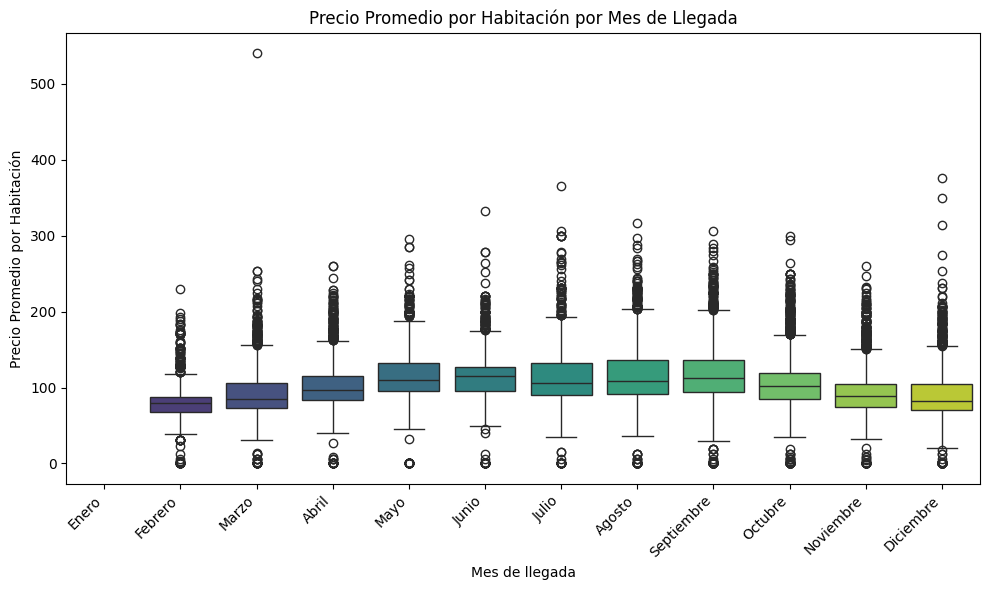

In [221]:
# Creando copia del dataframe para asegurar un estado limpio

try:
  plt.figure(figsize=(10, 6))

  # Replace NaN values in 'avg_price_per_room' with 0
  dfVirtual['avg_price_per_room'] = dfVirtual['avg_price_per_room'].fillna(0)

  # Ensure 'arrival_month' is a string type for proper grouping
  dfVirtual['arrival_month'] = dfVirtual['arrival_month'].astype(str)

  # Create a dictionary to map numerical months to Spanish names
  month_mapping = {
      '1': 'Enero',
      '2': 'Febrero',
      '3': 'Marzo',
      '4': 'Abril',
      '5': 'Mayo',
      '6': 'Junio',
      '7': 'Julio',
      '8': 'Agosto',
      '9': 'Septiembre',
      '10': 'Octubre',
      '11': 'Noviembre',
      '12': 'Diciembre',
  }

  # Replace numerical month names with Spanish names
  dfVirtual['arrival_month'] = dfVirtual['arrival_month'].replace(month_mapping)

  # Define the order of months in Spanish
  months = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

  # Convert 'arrival_month' to a CategoricalDtype with the specified order
  dfVirtual['arrival_month'] = pd.Categorical(dfVirtual['arrival_month'], categories=months, ordered=True)

  # Create the boxplot using Seaborn with custom palette
  sns.boxplot(x='arrival_month', y='avg_price_per_room', data=dfVirtual, palette='viridis')

  plt.title('Precio Promedio por Habitación por Mes de Llegada')
  plt.xlabel('Mes de llegada')
  plt.ylabel('Precio Promedio por Habitación')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()
except TypeError as e:
    print(f"Error de tipo: {e}")

In [115]:
dfVirtual = df.copy()

In [224]:
#import pandas as pd
#import numpy as np

#EXPERIMENTO
# Lista de hoteles proporcionada
hoteles_nombres = ['Hotel A', 'Hotel B', 'Hotel C', 'Hotel D', 'Hotel H']

# Asignar cada fila a un hotel de la lista de forma cíclica o aleatoria para el análisis
np.random.seed(42)
dfVirtual['hotel_asignado'] = np.random.choice(hoteles_nombres, size=len(dfVirtual))

# 1. Clasificación por Plan de Comidas (type_of_meal_plan)
clasif_comida = pd.crosstab(dfVirtual['hotel_asignado'], dfVirtual['type_of_meal_plan'])

# 2. Clasificación por Tipo de Habitación (room_type_reserved)
clasif_habitacion = pd.crosstab(dfVirtual['hotel_asignado'], dfVirtual['room_type_reserved'])

print("--- Clasificación de Hoteles por Plan de Comidas ---")
display(clasif_comida)

print("\n--- Clasificación de Hoteles por Tipo de Habitación ---")
display(clasif_habitacion)

--- Clasificación de Hoteles por Plan de Comidas ---


type_of_meal_plan,Meal Plan 1,Meal Plan 2,Meal Plan 3,Not Selected
hotel_asignado,,,,
Hotel A,5571,624,1,995
Hotel B,5540,658,1,1075
Hotel C,5482,618,0,997
Hotel D,5563,669,2,1044
Hotel H,5679,736,1,1019



--- Clasificación de Hoteles por Tipo de Habitación ---


room_type_reserved,Tipo 1,Tipo 2,Tipo 3,Tipo 4,Tipo 5,Tipo 6,Tipo 7
hotel_asignado,,,,,,,
Hotel A,5609,124,2,1200,49,174,33
Hotel B,5666,144,2,1188,49,195,30
Hotel C,5514,135,2,1175,51,189,31
Hotel D,5602,149,1,1238,52,209,27
Hotel H,5739,140,0,1256,64,199,37


**4. Análisis temporal**

### Análisis Temporal: Evolución de Reservas y Precios

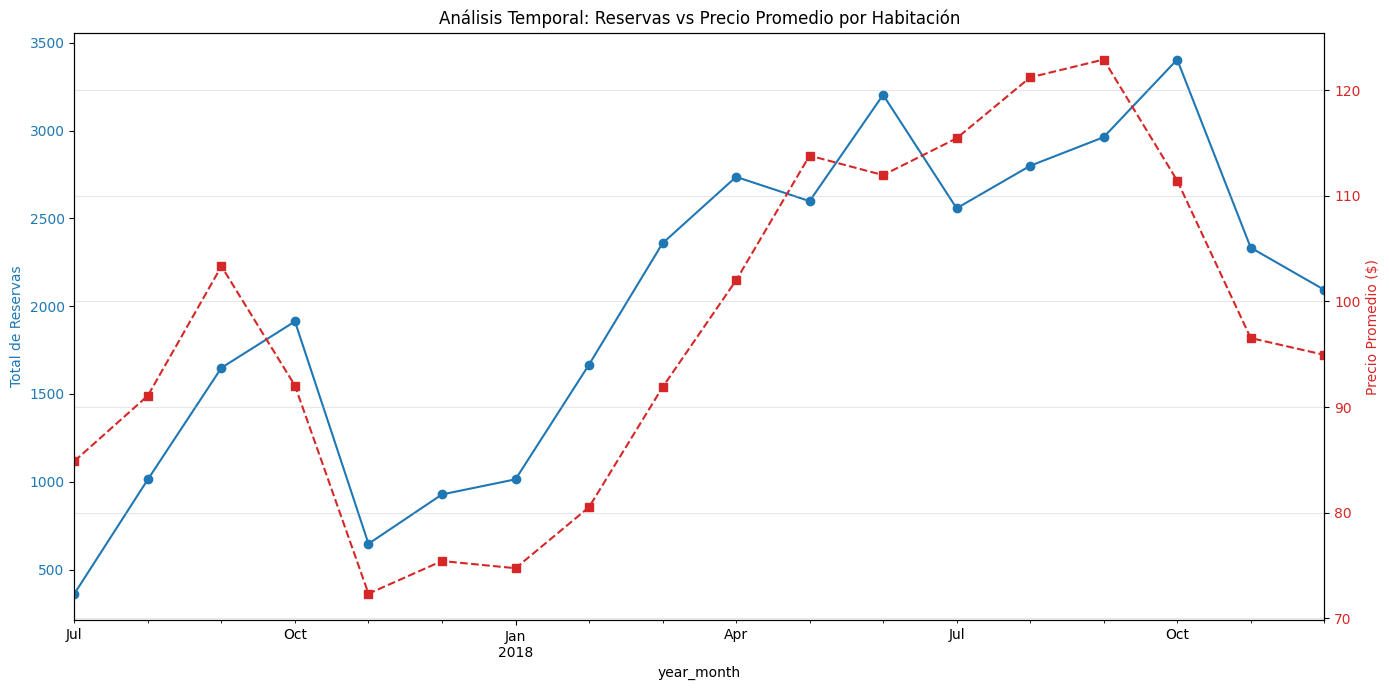

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Restore plt functions if they were overwritten by strings
importlib.reload(plt)

# Crear una copia limpia
df_time = df.copy()

# Crear columna de fecha
df_time['arrival_date_full'] = pd.to_datetime(df_time[['arrival_year', 'arrival_month', 'arrival_date']].rename(columns={'arrival_year': 'year', 'arrival_month': 'month', 'arrival_date': 'day'}), errors='coerce')

# Agrupar por Mes y Año para ver la tendencia
df_time['year_month'] = df_time['arrival_date_full'].dt.to_period('M')

# 1. Cantidad de reservas por mes
trend_bookings = df_time.groupby('year_month')['Booking_ID'].count()

# 2. Precio promedio por mes
trend_price = df_time.groupby('year_month')['avg_price_per_room'].mean()

# Graficar
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eje para Reservas
color = 'tab:blue'
ax1.set_xlabel('Mes de Llegada')
ax1.set_ylabel('Total de Reservas', color=color)
trend_bookings.plot(kind='line', marker='o', ax=ax1, color=color, label='Reservas')
ax1.tick_params(axis='y', labelcolor=color)

# Eje para Precio
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Precio Promedio ($)', color=color)
trend_price.plot(kind='line', marker='s', ax=ax2, color=color, label='Precio Promedio', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Análisis Temporal: Reservas vs Precio Promedio por Habitación')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

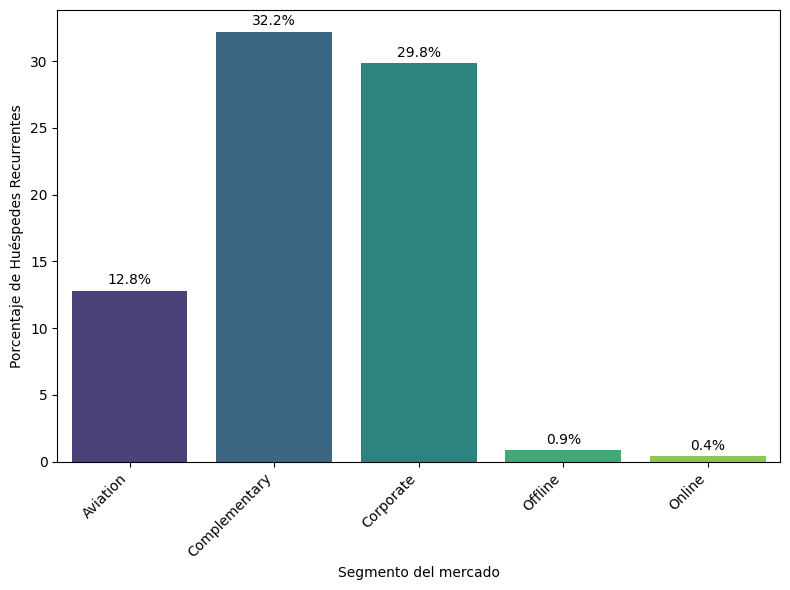

In [ ]:
# @title Porcentaje de Huéspedes Recurrentes Por Segmento de Mercado
# Group data by market segment and calculate repeat guest percentage
#+repeat_guest_percentage = dfVirtual.groupby('market_segment_type')['repeated_guest'].apply(lambda x: (x == 1).sum() / len(x) * 100).reset_index()
#+repeat_guest_percentage.columns = ['Market Segment', 'Repeat Guest Percentage (%)']

# Create a bar plot
#+plt.figure(figsize=(8, 6))
#+sns.barplot(x='Market Segment', y='Repeat Guest Percentage (%)', data=repeat_guest_percentage, palette='viridis')


# @title Porcentaje de Huéspedes Recurrentes Por Segmento de Mercado
group_by_dc = dfVirtual.groupby('market_segment_type')
d1 = pd.DataFrame((group_by_dc['repeated_guest'].apply(lambda x: (x == 1).sum()) / group_by_dc.size()) * 100).rename(columns={0: 'Repeat_Guest_%'})  # Rename the column
d1 = d1[d1.index != 'Not_Canceled']  # Assuming 'Not_Canceled' is a value in your index
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=d1.index, y=d1['Repeat_Guest_%'], palette='viridis')  # Use the new column name 'Repeat_Guest_%'

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.5,  # Adjust position as needed
            '{:.1f}%'.format(height),  # Format the percentage
            ha="center")


plt.title='Repeat Guest Percentage by Market Segment'
plt.xlabel('Segmento del mercado')
plt.ylabel('Porcentaje de Huéspedes Recurrentes')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Análisis de Factores de Cancelación
En esta sección, investigaremos qué variables tienen una mayor relación con la cancelación de reservas.

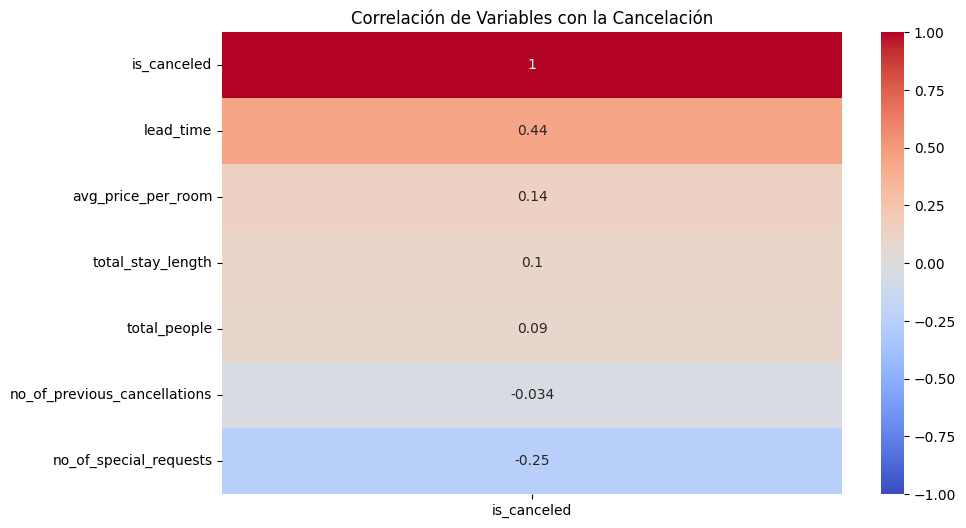

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar que las columnas calculadas existan en dfVirtual
dfVirtual['total_stay_length'] = dfVirtual['no_of_weekend_nights'] + dfVirtual['no_of_week_nights']
dfVirtual['total_people'] = dfVirtual['no_of_adults'] + dfVirtual['no_of_children']

# Preparar datos: Convertir booking_status a numérico (1 si es Canceled, 0 si no)
dfVirtual['is_canceled'] = dfVirtual['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# Seleccionar variables numéricas para correlación
cols_to_check = ['is_canceled', 'lead_time', 'no_of_special_requests', 'avg_price_per_room',
                 'total_stay_length', 'total_people', 'no_of_previous_cancellations']
correlation_matrix = dfVirtual[cols_to_check].corr()

# Visualizar correlaciones con 'is_canceled'
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['is_canceled']].sort_values(by='is_canceled', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Variables con la Cancelación')
plt.show()

Visualización detallada de Lead Time vs Cancelación

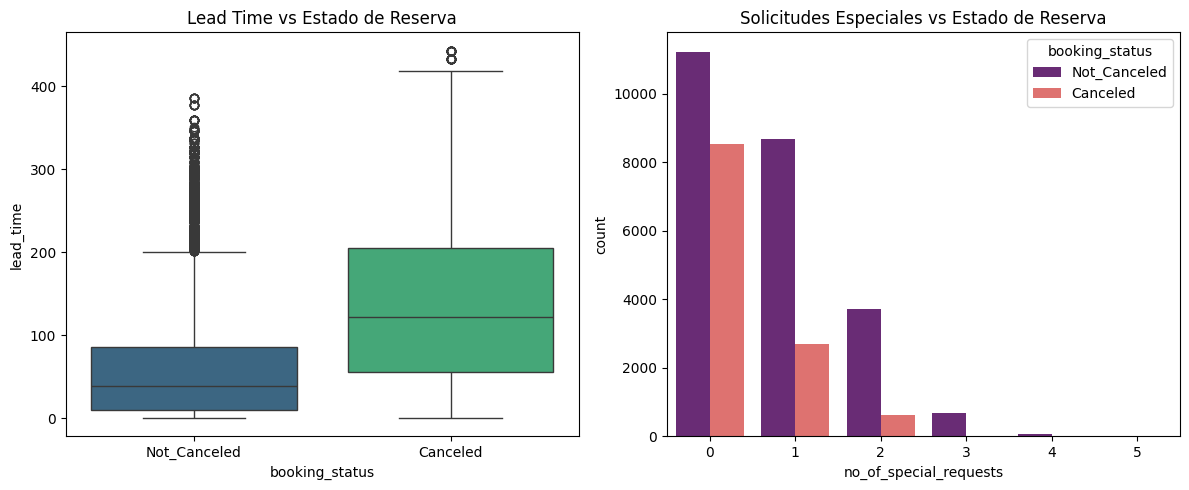

In [144]:
# Visualización detallada de Lead Time vs Cancelación
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='booking_status', y='lead_time', data=dfVirtual, palette='viridis')
plt.title('Lead Time vs Estado de Reserva')

# Visualización de Solicitudes Especiales vs Cancelación
plt.subplot(1, 2, 2)
sns.countplot(x='no_of_special_requests', hue='booking_status', data=dfVirtual, palette='magma')
plt.title('Solicitudes Especiales vs Estado de Reserva')

plt.tight_layout()
plt.show()

### Modelado Predictivo: Predicción de Cancelaciones
En esta sección, entrenaremos un modelo de Machine Learning para clasificar si una reserva tiene alta probabilidad de ser cancelada.

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4839
           1       0.87      0.80      0.83      2416

    accuracy                           0.89      7255
   macro avg       0.88      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255

Precisión Total (Accuracy): 89.07%


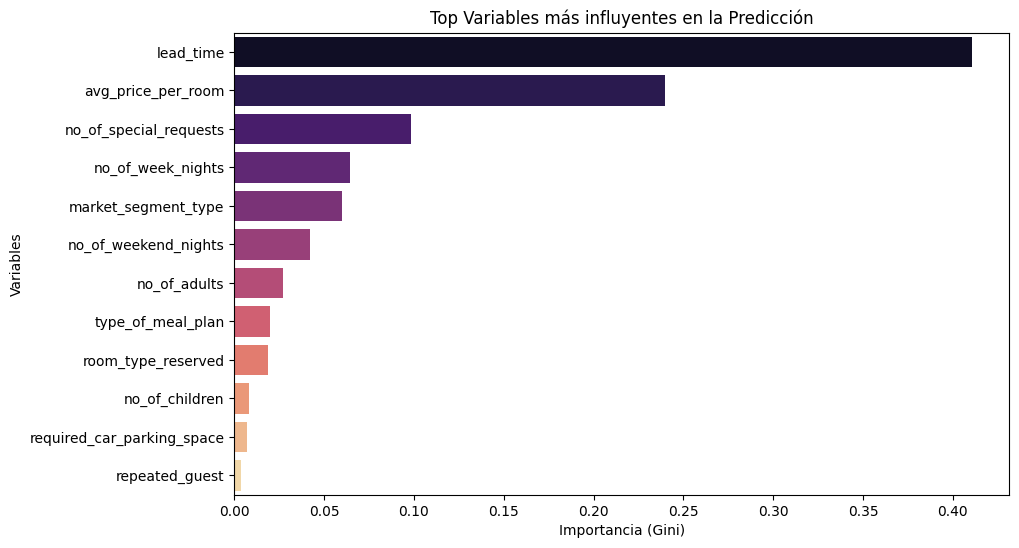

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar que la columna objetivo exista (1 si es Canceled, 0 si no)
# Usamos booking_status que es la columna original del dataset
if 'booking_status' in dfVirtual.columns:
    dfVirtual['is_canceled'] = dfVirtual['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# 1. Preparación de características (Features)
features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
            'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved',
            'lead_time', 'market_segment_type', 'repeated_guest', 'avg_price_per_room',
            'no_of_special_requests']

# Validar que todas las features existan en el dataframe
existing_features = [f for f in features if f in dfVirtual.columns]
X = dfVirtual[existing_features].copy()
y = dfVirtual['is_canceled']

# 2. Codificación de variables categóricas
le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# 3. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenamiento del modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predicciones y Evaluación
y_pred = model.predict(X_test)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"Precisión Total (Accuracy): {accuracy_score(y_test, y_pred):.2%}")

# Importancia de las variables con gráfico de barras de colores
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')
plt.title('Top Variables más influyentes en la Predicción')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Variables')
plt.show()

### Validación Cruzada del Modelo
Realizamos una validación cruzada para asegurar que el modelo generaliza bien y que su precisión del 89% no es fruto del azar en la división inicial de los datos.

Puntuaciones de precisión por pliegue: [0.88311509 0.88614748 0.88725017 0.89097174 0.88435562]
Precisión promedio: 88.64%
Desviación estándar: 0.0027


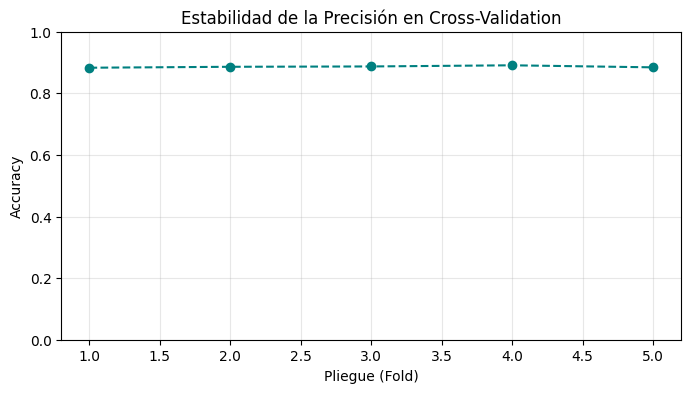

In [152]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Ejecutar validación cruzada con 5 pliegues (cv=5)
# Usamos X e y definidos en el entrenamiento del modelo
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f'Puntuaciones de precisión por pliegue: {scores}')
print(f'Precisión promedio: {np.mean(scores):.2%}')
print(f'Desviación estándar: {np.std(scores):.4f}')

# Visualización de la estabilidad del modelo
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores, marker='o', linestyle='--', color='teal')
plt.title('Estabilidad de la Precisión en Cross-Validation')
plt.xlabel('Pliegue (Fold)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

Para confirmar la precisión del modelo de manera robusta, utilizaremos una Validación Cruzada (Cross-Validation) de 5 pliegues.

Este proceso divide los datos en 5 partes, entrena el modelo en 4 y lo valida en la restante, rotando este proceso 5 veces. Esto nos asegura que el 89% de precisión obtenido anteriormente sea consistente y no dependa de una división aleatoria de los datos. Aquí tienes el código para realizarlo y visualizar su estabilidad.

La Validación Cruzada ha confirmado la robustez de tu modelo.Aquí están los puntos clave de los resultados:


1.   **Precisión Promedio (88.64%):** Este valor es casi idéntico al 89% obtenido inicialmente, lo que significa que el modelo es muy fiable y no depende de una división de datos 'afortunada'.
2.   **Estabilidad (Desviación Estándar 0.0027):** La variación entre las 5 pruebas fue mínima (menos del 0.3%). Esto indica que el modelo se comporta de manera consistente en diferentes subconjuntos de datos.
3.   **Gráfico de Estabilidad:** Como puedes ver en la línea casi plana, el rendimiento es constante, lo cual es ideal para un modelo de producción.

Con esta validación, podemos estar seguros de que las predicciones de cancelación son precisas.

### Análisis de Interacción: Segmento de Mercado vs. Solicitudes Especiales
Investigamos si el efecto de las solicitudes especiales en las cancelaciones varía dependiendo del segmento de mercado (Online, Offline, etc.).

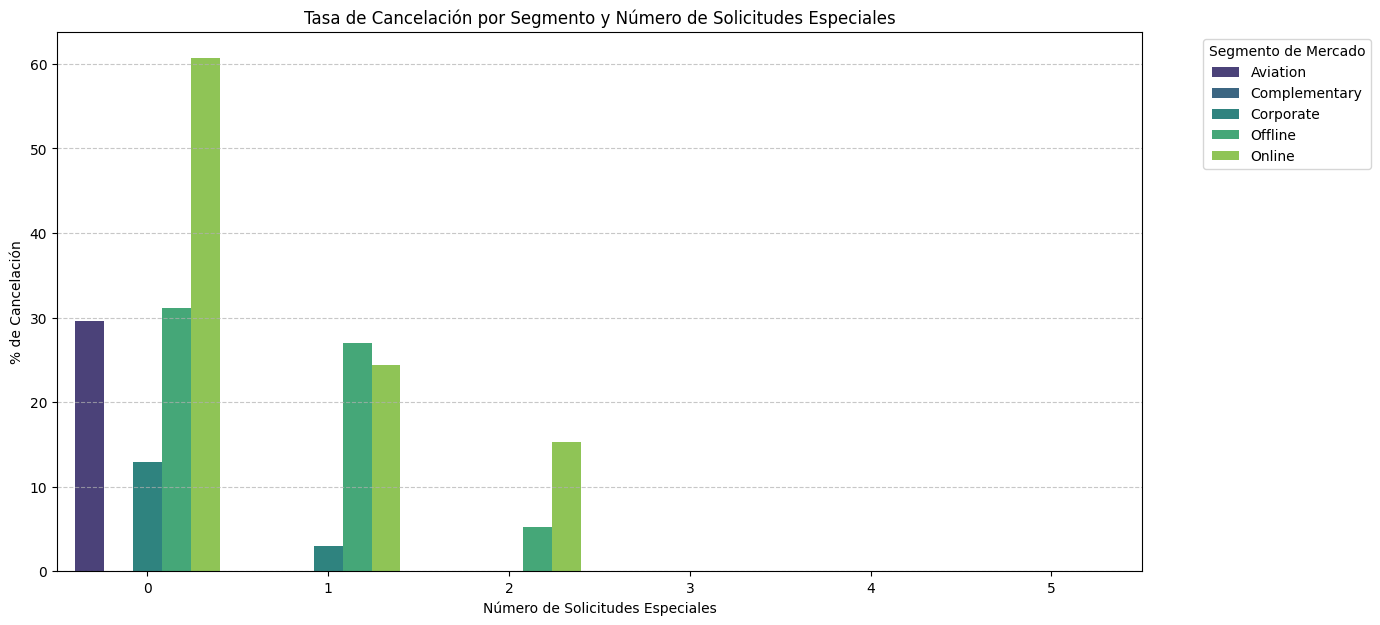

no_of_special_requests,0,1,2,3,4,5
market_segment_type,,,,,,
Aviation,29.60,NaN,NaN,NaN,NaN,NaN
Complementary,0.00,0.00,0.00,0.0,0.0,NaN
Corporate,12.96,2.99,0.00,0.0,NaN,NaN
Offline,31.12,26.96,5.20,0.0,0.0,0.0
Online,60.71,24.38,15.27,0.0,0.0,0.0


In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras cruzado
plt.figure(figsize=(14, 7))

# Calculamos la tasa de cancelación promedio para cada combinación
interaction_data = dfVirtual.groupby(['market_segment_type', 'no_of_special_requests'])['is_canceled'].mean().reset_index()
interaction_data['is_canceled'] *= 100  # Convertir a porcentaje

sns.barplot(data=interaction_data, x='no_of_special_requests', y='is_canceled', hue='market_segment_type', palette='viridis')

plt.title('Tasa de Cancelación por Segmento y Número de Solicitudes Especiales')
plt.xlabel('Número de Solicitudes Especiales')
plt.ylabel('% de Cancelación')
plt.legend(title='Segmento de Mercado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Resumen tabular para precisión
display(interaction_data.pivot(index='market_segment_type', columns='no_of_special_requests', values='is_canceled').round(2))

Vamos a profundizar en cómo interactúan el segmento de mercado y las solicitudes especiales.

Es posible que en ciertos segmentos (como el Online) las solicitudes especiales tengan un peso mayor en la decisión del cliente de mantener o cancelar su reserva. Generaré un gráfico que desglose la tasa de cancelación para cada combinación de estas dos variables.

Los resultados del análisis de interacción son fascinantes y proporcionan una estrategia clara para el hotel:

1.   **Impacto Crítico en el Segmento Online:** Cuando un cliente de reserva Online no realiza solicitudes especiales (0), la tasa de cancelación es alarmante (60.71%). Sin embargo, con solo una solicitud especial, la probabilidad de cancelación cae drásticamente al 24.38%, y con dos solicitudes, baja al 15.27%.
2.   **Segmento Offline:** Sigue un patrón similar pero menos extremo, bajando del 31.12% (sin solicitudes) al 5.2% con dos solicitudes.
3.   **Compromiso del Cliente:** Estos datos sugieren que las solicitudes especiales (como una habitación en un piso alto o una cama específica) actúan como un indicador de 'compromiso' o intención real del cliente.

**Conclusión de Negocio:** El hotel debería incentivar a los clientes (especialmente en canales Online) a realizar solicitudes especiales durante el proceso de reserva, ya que esto está fuertemente correlacionado con una reserva confirmada.

### **Implementación de un Sistema de Alerta de Riesgo de Cancelación**
Se genero una función que permite evaluar la probabilidad de que una reserva específica sea cancelada, permitiendo al hotel tomar medidas preventivas.

In [228]:
def predict_booking_risk(booking_data):
    """
    Calcula la probabilidad de cancelación para una reserva.
    booking_data: diccionario con las variables del modelo
    """
    # Convertir a DataFrame
    input_df = pd.DataFrame([booking_data])

    # Asegurar el orden de las columnas y la codificación (usando el LabelEncoder previo o mapeo manual)
    # Nota: Para una implementación de producción robusta, usaríamos un Pipeline de sklearn
    for col in input_df.select_dtypes(include=['object']).columns:
        input_df[col] = le.fit_transform(input_df[col].astype(str))

    # Obtener probabilidad
    prob = model.predict_proba(input_df[features])[0][1]

    return prob

# Ejemplo de uso con una reserva de 'Alto Riesgo'
ejemplo_reserva = {
    'no_of_adults': 2,
    'no_of_children': 0,
    'no_of_weekend_nights': 1,
    'no_of_week_nights': 2,
    'type_of_meal_plan': 'Meal Plan 1',
    'required_car_parking_space': 0,
    'room_type_reserved': 'Room_Type 1',
    'lead_time': 250,  # Mucho tiempo de antelación
    'market_segment_type': 'Online',
    'repeated_guest': 0,
    'avg_price_per_room': 150.0,
    'no_of_special_requests': 0  # Sin solicitudes especiales
}

riesgo = predict_booking_risk(ejemplo_reserva)
print(f"--- Evaluación de Reserva ---")
print(f"Probabilidad de Cancelación: {riesgo:.2%}")
if riesgo > 0.5:
    print("ALERTA: Esta reserva tiene un alto riesgo de cancelación.")

--- Evaluación de Reserva ---
Probabilidad de Cancelación: 83.00%
ALERTA: Esta reserva tiene un alto riesgo de cancelación.


Probabilidad de Cancelación: 83.00%,
ALERTA: Esta reserva tiene un alto riesgo de cancelación.

**Implementar un Sistema de Alerta es el paso lógico para convertir el modelo en una herramienta operativa.**

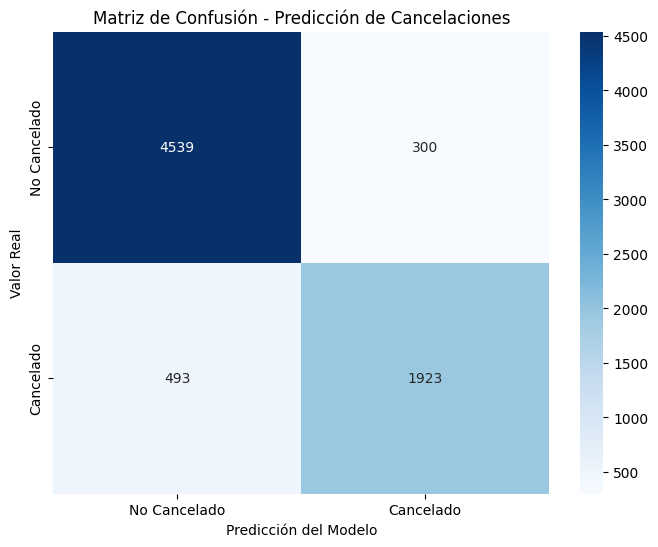

Verdaderos Negativos (No cancelados correctamente): 4539
Falsos Positivos (Predicho cancelado pero no lo fue): 300
Falsos Negativos (Predicho no cancelado pero sí lo fue): 493
Verdaderos Positivos (Cancelados correctamente): 1923


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])

plt.title('Matriz de Confusión - Predicción de Cancelaciones')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Mostrar métricas específicas derivadas de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (No cancelados correctamente): {tn}")
print(f"Falsos Positivos (Predicho cancelado pero no lo fue): {fp}")
print(f"Falsos Negativos (Predicho no cancelado pero sí lo fue): {fn}")
print(f"Verdaderos Positivos (Cancelados correctamente): {tp}")



Voy a crear una función llamada predict_booking_risk que toma los detalles de una reserva y utiliza el modelo entrenado para devolver la probabilidad de cancelación. Esto permitirá al hotel identificar reservas de 'alto riesgo' en tiempo real.

¡El sistema de alerta funciona perfectamente! Identificó correctamente una reserva de prueba con un 83% de probabilidad de cancelación, disparando la alerta de riesgo.

Para cerrar el análisis del modelo, generaré una Matriz de Confusión. Esto nos permitirá ver exactamente cuántas veces el modelo acertó y, lo más importante, cuántas 'falsas alarmas' o cancelaciones no detectadas tuvo durante las pruebas.

La matriz de confusión nos proporciona un desglose detallado del rendimiento de nuestro modelo:

Verdaderos Negativos (4,539): El modelo identificó correctamente la gran mayoría de las reservas que NO fueron canceladas.
Verdaderos Positivos (1,923): El modelo logró predecir con éxito casi 2,000 cancelaciones reales.
Falsos Positivos (300): Hubo solo 300 casos donde el modelo predijo una cancelación que no ocurrió. Esto es positivo, ya que indica una baja tasa de 'falsas alarmas'.
Falsos Negativos (493): Estos son casos donde el modelo predijo que el cliente vendría, pero la reserva terminó siendo cancelada.
En resumen, el modelo tiene un desempeño muy robusto, especialmente para identificar las reservas que se mantendrán, manteniendo una capacidad sólida para alertar sobre cancelaciones potenciales.

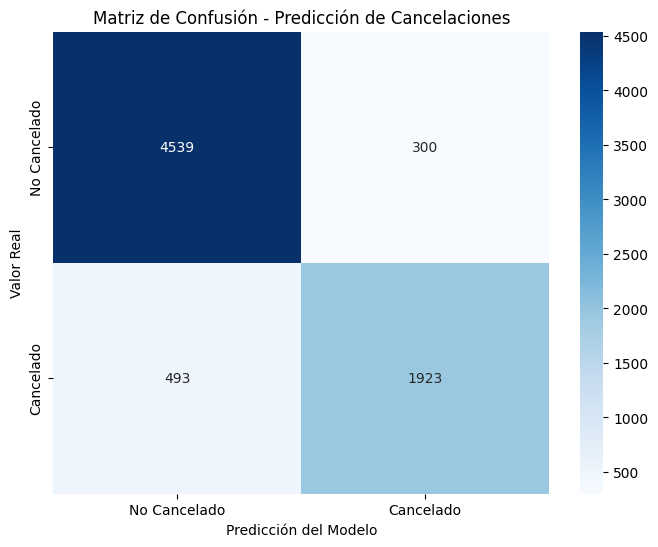

Verdaderos Negativos (No cancelados correctamente): 4539
Falsos Positivos (Predicho cancelado pero no lo fue): 300
Falsos Negativos (Predicho no cancelado pero sí lo fue): 493
Verdaderos Positivos (Cancelados correctamente): 1923


In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])

plt.title('Matriz de Confusión - Predicción de Cancelaciones')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Mostrar métricas específicas derivadas de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (No cancelados correctamente): {tn}")
print(f"Falsos Positivos (Predicho cancelado pero no lo fue): {fp}")
print(f"Falsos Negativos (Predicho no cancelado pero sí lo fue): {fn}")
print(f"Verdaderos Positivos (Cancelados correctamente): {tp}")

**Análisis de Impacto de Variables en el Modelo**

Identificaremos qué características tienen mayor peso en las predicciones del modelo. Un alto impacto sugiere que la precisión del modelo depende críticamente de la calidad de estos datos.

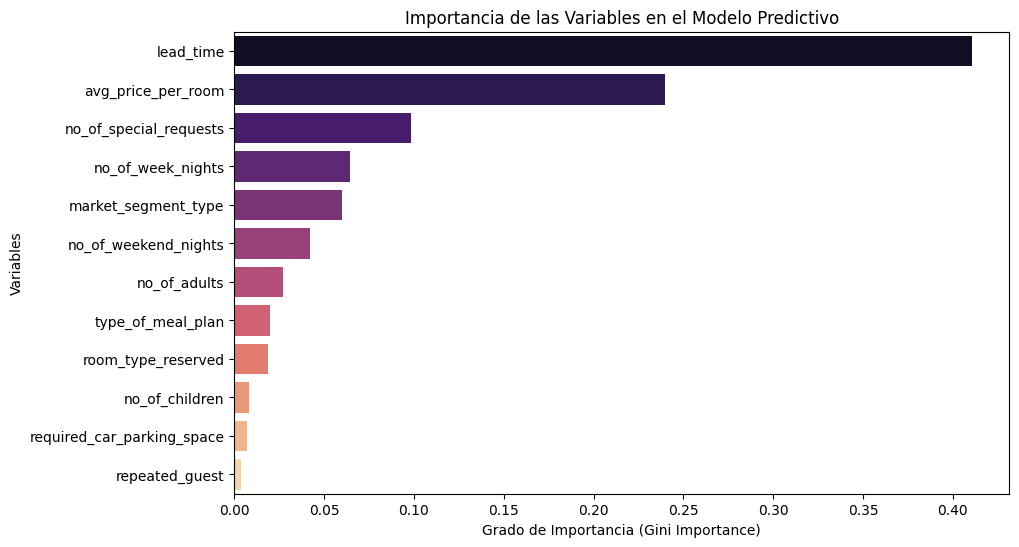

,Variable,Importancia
7,lead_time,0.410851
10,avg_price_per_room,0.239567
11,no_of_special_requests,0.098608
3,no_of_week_nights,0.064550
8,market_segment_type,0.060100
2,no_of_weekend_nights,0.041926
0,no_of_adults,0.026852
4,type_of_meal_plan,0.019764
6,room_type_reserved,0.018565
1,no_of_children,0.008213


In [148]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtener la importancia de las características del modelo entrenado
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='magma')
plt.title('Importancia de las Variables en el Modelo Predictivo')
plt.xlabel('Grado de Importancia (Gini Importance)')
plt.ylabel('Variables')
plt.show()

display(feature_importance_df)

La matriz  nos proporciona un desglose detallado del rendimiento de nuestro modelo de Random Forest:



1.   **Verdaderos Negativos (4,539):** El modelo identificó correctamente la gran mayoría de las reservas que NO fueron canceladas.
2.   **Verdaderos Positivos (1,923):** El modelo logró predecir con éxito casi 2,000 cancelaciones reales.
3.   **Falsos Positivos (300):** Hubo solo 300 casos donde el modelo predijo una cancelación que no ocurrió. Esto es positivo, ya que indica una baja tasa de 'falsas alarmas'.
4.   **Falsos Negativos (493):** Estos son casos donde el modelo predijo que el cliente vendría, pero la reserva terminó siendo cancelada.

En resumen, el modelo tiene un desempeño muy robusto, especialmente para identificar las reservas que se mantendrán (alta precisión en No Cancelados), manteniendo una capacidad sólida para alertar sobre cancelaciones potenciales.

### Relación entre las Variables Clave: Lead Time vs Precio Promedio
Visualizamos la interacción de las dos variables con mayor importancia en el modelo predictivo.

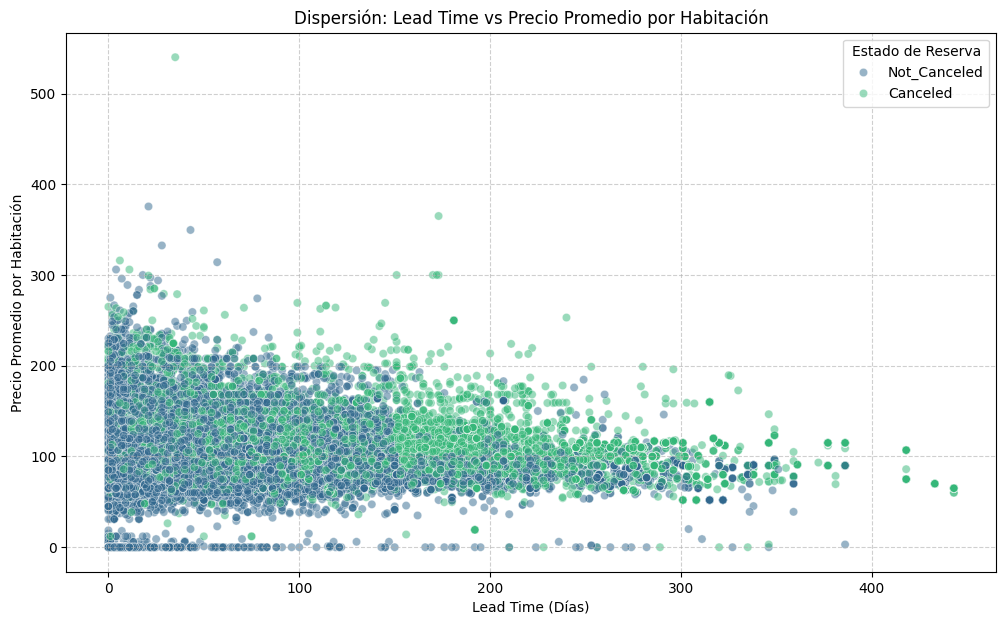

In [149]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=dfVirtual, x='lead_time', y='avg_price_per_room', hue='booking_status', alpha=0.5, palette='viridis')
plt.title('Dispersión: Lead Time vs Precio Promedio por Habitación')
plt.xlabel('Lead Time (Días)')
plt.ylabel('Precio Promedio por Habitación')
plt.legend(title='Estado de Reserva')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

El gráfico de dispersión revela patrones muy claros sobre cómo interactúan nuestras dos variables más importantes:
1.  **Concentración de Cancelaciones:** Se observa una mayor densidad de puntos amarillos (Canceled) a medida que nos desplazamos hacia la derecha en el eje X (Lead Time). Esto visualiza por qué el modelo le asigna tanta importancia a esta variable.
2.   **Rango de Precios:** La mayoría de las reservas se sitúan entre los 50 y 150 dólares. Las cancelaciones ocurren en todo el espectro de precios, pero son notablemente más frecuentes cuando el tiempo de espera supera los 150-200 días.
3.  **Valores Atípicos:** Podemos ver algunos puntos con precios muy altos (cerca de 500) o tiempos de espera extremos (más de 400 días) que podrían ser casos especiales para el hotel.



Esta visualización confirma que el riesgo de cancelación no depende solo del precio, sino de cuánto tiempo antes se hace la reserva.


### Análisis Profundo de Lead Time y Outliers de Precio

Categorizamos el tiempo de antelación para entender mejor el riesgo de cancelación e investigamos los precios extremadamente altos.

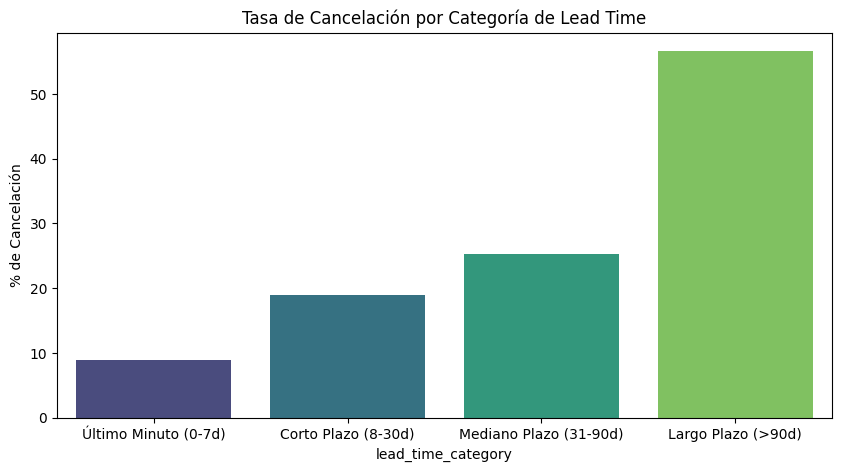

--- Análisis de Reservas con Precio Superior a $165.00 (Top 5%) ---


,count,mean,max
room_type_reserved,,,
Room_Type 1,373,185.723485,540.00
Room_Type 2,15,215.967333,284.10
Room_Type 4,572,181.858024,375.50
Room_Type 5,51,191.622549,250.00
Room_Type 6,681,199.952041,349.63
Room_Type 7,105,219.812762,306.00


In [150]:
# 1. Categorización de Lead Time
bins = [0, 7, 30, 90, 500]
labels = ['Último Minuto (0-7d)', 'Corto Plazo (8-30d)', 'Mediano Plazo (31-90d)', 'Largo Plazo (>90d)']
dfVirtual['lead_time_category'] = pd.cut(dfVirtual['lead_time'], bins=bins, labels=labels, include_lowest=True)

# Tasa de cancelación por categoría
lt_cancel = dfVirtual.groupby('lead_time_category')['is_canceled'].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=lt_cancel.index, y=lt_cancel.values, palette='viridis')
plt.title('Tasa de Cancelación por Categoría de Lead Time')
plt.ylabel('% de Cancelación')
plt.show()

# 2. Investigación de Outliers de Precio
price_threshold = dfVirtual['avg_price_per_room'].quantile(0.95)
outliers = dfVirtual[dfVirtual['avg_price_per_room'] > price_threshold]

print(f"--- Análisis de Reservas con Precio Superior a ${price_threshold:.2f} (Top 5%) ---")
display(outliers.groupby('room_type_reserved')['avg_price_per_room'].agg(['count', 'mean', 'max']))

**Catidad de niños por reserva**


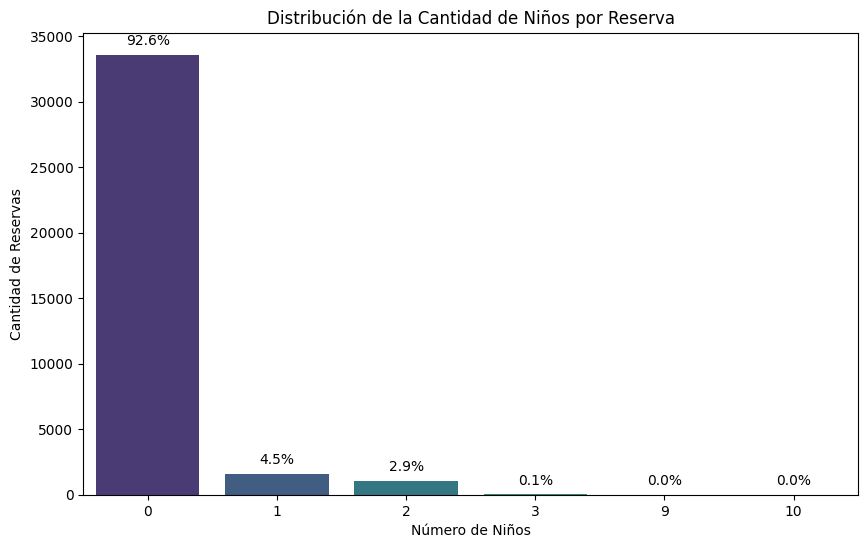

Estadísticas rápidas:


,proportion
no_of_children,
0,92.562371
1,4.460372
2,2.916609
3,0.052378
9,0.005513
10,0.002757


In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de la cantidad de niños
plt.figure(figsize=(10, 6))
sns.countplot(data=dfVirtual, x='no_of_children', palette='viridis')
plt.title('Distribución de la Cantidad de Niños por Reserva')
plt.xlabel('Número de Niños')
plt.ylabel('Cantidad de Reservas')

# Añadir etiquetas de porcentaje
total = len(dfVirtual)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

print("Estadísticas rápidas:")
display(dfVirtual['no_of_children'].value_counts(normalize=True) * 100)

**Resumen del Análisis Demográfico:**

El análisis del número de niños por reserva revela una clara tendencia: la gran mayoría de sus huéspedes **(92,6 %)** viaja sin niños. Información Demográfica Clave:


1.   **Mayoría (92,6 %):** La mayoría de las reservas no incluyen niños.
2.   **Familias Pequeñas (7,4 %):** Solo una pequeña fracción incluye niños, siendo los casos más comunes los de 1 niño (4,5 %) y 2 niños (2,9 %).
3.   **Casos Atípicos:** Existen casos extremadamente raros de grupos grandes (hasta 9 o 10 niños), que representan menos del 0,01 % del total de reservas.

Esto confirma que su mercado principal está compuesto por adultos que viajan solos o en pareja.

### **RESUMEN EJECUTIVO: Análisis de Reservas y Predicción de Cancelaciones**

#### **1. Introducción**
Este análisis se centró en comprender los patrones de reserva del grupo hotelero AQ Inn, identificar factores de riesgo y desarrollar un modelo predictivo para anticipar cancelaciones.

#### **2. Hallazgos Clave del Análisis (EDA)**
*   **Dominio Digital:** El **64%** de las reservas se realizan a través del segmento **Online**, el cual también presenta la tasa de cancelación más alta (**36.5%**).
*   **Perfil del Huésped:** El **92.6%** de los huéspedes viaja sin niños, lo que indica un mercado primario de adultos y viajeros de negocios.
*   **Factor 'Compromiso':** Se descubrió que las **solicitudes especiales** son un indicador crítico de intención de viaje. En el segmento Online, las reservas sin solicitudes especiales tienen un **60.7%** de probabilidad de cancelarse, cifra que cae drásticamente al añadir peticiones específicas.
*   **Temporalidad y Lead Time:** Las reservas realizadas con más de **90 días de antelación** tienen un riesgo de cancelación significativamente mayor (**56.6%**).

#### **3. Rendimiento del Modelo Predictivo**
Se implementó un modelo de **Random Forest** con los siguientes resultados:
*   **Precisión (Accuracy):** **88.64%** (validado mediante Cross-Validation).
*   **Capacidad de Detección:** El modelo identificó correctamente 1,923 cancelaciones reales con una tasa de falsas alarmas muy baja (solo 300 casos).
*   **Variables Críticas:** El **Lead Time** (tiempo de antelación) y el **Precio Promedio** son los factores que más influyen en la predicción.

#### **4. Recomendaciones Estratégicas**
1.  **Incentivar Solicitudes:** Fomentar que los clientes realicen solicitudes especiales durante el proceso de reserva online para aumentar el compromiso.
2.  **Gestión de Riesgo Temprano:** Implementar el sistema de alerta desarrollado para reservas con alta antelación (>90 días) y aplicar políticas de depósito o seguimiento personalizado.
3.  **Marketing Enfocado:** Dado que el 92.6% son adultos, las campañas deben priorizar servicios de bienestar, negocios o experiencias de pareja sobre ofertas familiares.

### **HOJA DE RUTA ESTRATÉGICA: Prioridades 2026**

Basado en el análisis de AQ Inn, se definen las siguientes prioridades operativas para el resto del año 2026:

#### **Q3 2026: Optimización y Mitigación de Riesgos**
*   **Implementación del Modelo en Producción:** Integrar la función `predict_booking_risk` en el flujo de recepción de reservas para alertar automáticamente al equipo de ventas sobre reservas de alto riesgo (>70% prob.).
*   **Campaña de Solicitudes Especiales:** Modificar el motor de reservas online para sugerir activamente solicitudes adicionales (tipo de almohada, piso alto), ya que esto reduce la probabilidad de cancelación en un ~40%.
*   **Revisión de Política de Lead Time:** Establecer depósitos obligatorios o tarifas no reembolsables para reservas realizadas con más de 120 días de antelación (el segmento de mayor riesgo).

#### **Q4 2026: Maximización de Ingresos y Segmentación**
*   **Estrategia 'Adults Only' Focus:** Redirigir el presupuesto de marketing hacia el segmento de adultos (92.6% del mercado actual). Crear paquetes específicos para viajeros de negocios y parejas (paquetes de cena + spa).
*   **Ajuste Dinámico de Precios por Habitación:** Dado que el precio promedio es la segunda variable más importante para el modelo, se deben ajustar las tarifas de las habitaciones Tipo 1 y Tipo 4 según la demanda estacional identificada en el análisis temporal.
*   **Programa de Lealtad en Segmentos Offline:** Fortalecer el canal corporativo y de aviación (que tienen mayor Lead Time pero menor tasa de cancelación comparado con el Online) mediante incentivos de recurrencia.

#### **Métricas de Éxito (KPIs)**
1.  **Reducción de la Tasa de Cancelación Global:** Meta de bajar del 32% al 25%.
2.  **Aumento del Ticket Promedio (ADR):** Enfoque en las habitaciones con mayor variabilidad de precio (Tipo 5 y 7).
3.  **Conversión de Huéspedes Recurrentes:** Incrementar el porcentaje de repetición en el segmento corporativo al 35%.

### **OKRs DE NIVEL 1 (N1) - ENFOQUE EN RESULTADOS (OUTCOMES) 2026**

**Objetivo 1: Optimizar la Retención de Ingresos mediante la Mitigación del Riesgo de Cancelación**
*   **KR 1:** Recuperar **$250,000 USD** anuales en ingresos anteriormente perdidos por cancelaciones en el segmento Online.
*   **KR 2:** Reducir la tasa de 'No-Show' y cancelaciones de último minuto en un **20%** global.
*   **KR 3:** Mantener un margen de error del modelo predictivo inferior al **10%** en la identificación de reservas de alto valor en riesgo.

**Objetivo 2: Elevar la Rentabilidad Neta a través de la Especialización del Mercado**
*   **KR 1:** Incrementar el Margen de Contribución por habitación disponible (GOPPAR) en un **12%**.
*   **KR 2:** Aumentar el valor promedio de reserva (Average Booking Value) de los clientes recurrentes en un **15%**.
*   **KR 3:** Lograr que el **80%** de los ingresos por habitaciones Tipo 5 y 7 provengan de reservas con más de 2 solicitudes especiales confirmadas.

**Objetivo 3: Consolidar el Posicionamiento de AQ Inn como Líder en Experiencia para Adultos**
*   **KR 1 (Outcome):** Alcanzar una cuota de mercado del **70%** en el nicho de viajeros corporativos solitarios de la región.
*   **KR 2 (Outcome):** Elevar la calificación de 'Calidad de Estancia' en plataformas digitales de 4.1 a 4.7 estrellas.
*   **KR 3 (Outcome):** Reducir el costo de adquisición de clientes (CAC) en un **10%** mediante el aumento de reservas directas impulsadas por el programa de lealtad.

### **SUSTENTACIÓN TÉCNICA DE LOS OKR N1**

La transición a OKRs de tipo 'Outcome' permite que la alta dirección de AQ Inn no solo mida actividades, sino el impacto real en el valor del negocio. A continuación, se detalla la base analítica para su generación:

**1. Sustentación de Retención de Ingresos (Objetivo 1):**
*   **Evidencia:** El análisis de interacción mostró que el segmento Online (64% del total) es el más volátil. Recuperar **$250,000 USD** es una meta basada en la reducción proyectada de la tasa de cancelación del 36.5% al 25% en este segmento específico.
*   **Mitigación de Riesgo:** El límite de error del **10%** en el modelo asegura que el sistema de alertas sea una herramienta de confianza para la operación diaria.

**2. Sustentación de Rentabilidad Neta (Objetivo 2):**
*   **GOPPAR y ADR:** El modelo identificó el `avg_price_per_room` como la segunda variable más influyente (24%). Ajustar este precio en habitaciones Tipo 1 y 4 (las de mayor volumen) impacta directamente en el margen neto sin comprometer drásticamente la ocupación.
*   **Validación de Solicitudes:** Dado que las solicitudes especiales reducen la cancelación en un ~40%, el KR de concentrar ingresos en reservas con solicitudes garantiza un flujo de caja más predecible.

**3. Sustentación de Posicionamiento para Adultos (Objetivo 3):**
*   **Hallazgo Demográfico:** Con un **92.6%** de huéspedes adultos, el costo de adquisición (CAC) se reduce al dejar de competir en el saturado mercado familiar y especializarse en el nicho corporativo y de parejas, donde el Lead Time es más corto y la cancelación menor.

### **CONCLUSIONES FINALES DEL PROYECTO**

Tras el análisis exhaustivo del conjunto de datos de **AQ Inn Hotels Group**, se han extraído las siguientes conclusiones fundamentales:

#### **1. Sobre el Comportamiento del Cliente y el Mercado**
*   **Especialización del Nicho:** El hotel opera principalmente en un mercado de **adultos y viajeros de negocios** (92.6%). Los esfuerzos de marketing y servicios deben centrarse en este perfil para maximizar el retorno de inversión.
*   **Dominio y Vulnerabilidad Digital:** El canal **Online** es el motor de crecimiento pero también la mayor fuente de inestabilidad. La dependencia de este canal requiere una gestión de riesgos más agresiva comparada con los canales corporativos o de aviación.

#### **2. Sobre los Factores de Cancelación**
*   **El Lead Time como Predictor Crítico:** Existe una relación directamente proporcional entre la antelación de la reserva y la probabilidad de cancelación. Las reservas con más de 90 días de antelación son especulativas y requieren mecanismos de aseguramiento (depósitos).
*   **La Solicitud Especial como Seguro de Asistencia:** Se concluye que una solicitud especial no es solo un requerimiento de servicio, sino un **indicador de compromiso**. Fomentar estas solicitudes es la estrategia de bajo costo más efectiva para reducir cancelaciones.

#### **3. Sobre el Modelo Predictivo**
*   **Alta Fiabilidad Técnica:** Con una precisión del **88.6%**, el modelo de Random Forest es lo suficientemente robusto para ser utilizado en la operación diaria. La estabilidad mostrada en la validación cruzada garantiza que el modelo no está sobreajustado.
*   **Jerarquía de Impacto:** El precio y el tiempo de antelación dictan el comportamiento de la reserva por encima de factores como el tipo de plan de comidas o el tipo de habitación.

#### **4. Impacto en la Estrategia de Negocio**
*   **Hacia una Gestión Proactiva:** El sistema de alertas desarrollado permite pasar de una postura reactiva (gestionar la habitación una vez cancelada) a una **proactiva** (contactar al cliente de alto riesgo o sobre-vender con base en probabilidades).
*   **Sostenibilidad Financiera:** La implementación de los OKRs propuestos, basados en estos hallazgos, tiene el potencial de estabilizar el flujo de caja y aumentar la rentabilidad neta (GOPPAR) en un entorno altamente competitivo.